In [6]:
# %% Cell 0 — activate env in .. + imports (NOW includes JLD2)
import Pkg
Pkg.activate("..")
Pkg.instantiate()

using JLD2                      # <-- requested
using FFTW
using LinearAlgebra
using CairoMakie
using Base.Threads

# (optional, only if you use these later)
using QuantumToolbox
using ColorSchemes
using MathTeXEngine

⊗ = kron

  Activating project at `~/Documents/GitHub/robust_control_sam/src`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651


kron (generic function with 54 methods)

In [14]:
import Pkg; Pkg.activate(".."); Pkg.instantiate();
Pkg.develop(path="../../../QuantumCollocation.jl")
using PiccoloQuantumObjects
using QuantumCollocation
using ForwardDiff
using LinearAlgebra
using SparseArrays
using Statistics
using CairoMakie
using Random
using NamedTrajectories
⊗ = kron;

θ = pi / 10

# variational objective metric
function var_obj(
    traj::NamedTrajectory, 
    H_drift::Matrix{ComplexF64},
    H_drives::Vector{Matrix{ComplexF64}}, 
    H_errors::Vector{Matrix{ComplexF64}}
)
    Δt = traj.Δt[1]
    T = traj.T
    varsys = VariationalQuantumSystem(H_drift, H_drives, H_errors)
    Ũ⃗, ∂Ũ⃗ = variational_unitary_rollout(traj, varsys)

    U = iso_vec_to_operator(Ũ⃗[:, end])
    # First error term
    ∂U = iso_vec_to_operator(∂Ũ⃗[1][:, end])

    d = size(U, 1)
    return abs(tr((U'*∂U)'*(U'*∂U))) / ((T-1) * Δt)^2 / d
end

function scatter_with_line!(ax, x, y; color, label)
    lines!(ax, x, y; color=color, linewidth=2)         # connect points
    scatter!(ax, x, y; color=color, marker=:circle, 
                markersize=8, label=label)                 # overlay dots + legend
end

# Problem parameters
seed = 1
println("============|Starting random seed $seed|============")
var_avg_vec = [] # ZZ, Z1, Z2 average
def_avg_vec = []
uni_avg_vec = []

var_full_vec = []
def_full_vec = []
uni_full_vec = []

var_F = []
def_F = []
uni_F = []

#ä_vals = exp10.(range(-2, stop = 3, length = 10))
ä = 10.0
ä_vals = [ä]
F = 0.9999 # target fidelity
T = 50
Δt = 0.2
num_iter = 1000
iSWAP = exp(1.0im * π / 4 * (PAULIS.X ⊗ PAULIS.X + PAULIS.Y ⊗ PAULIS.Y))
V_dag = exp(1.0im * θ * (PAULIS.X ⊗ PAULIS.X + PAULIS.Y ⊗ PAULIS.Y))
U_goal = V_dag * iSWAP * V_dag
a_bound = 5.0
println("============|Acceleration is $ä|============")

X1 = GATES.X ⊗ GATES.I
Y1 = GATES.Y ⊗ GATES.I
Z1 = GATES.Z ⊗ GATES.I
X2 = GATES.I ⊗ GATES.X
Y2 = GATES.I ⊗ GATES.Y
Z2 = GATES.I ⊗ GATES.Z
XX = GATES.X ⊗ GATES.X # transversal coupling
YY = GATES.Y ⊗ GATES.Y # transversal coupling
ZZ = GATES.Z ⊗ GATES.Z # transverse coupling, for error comparison
XY = GATES.X ⊗ GATES.Y
YX = GATES.Y ⊗ GATES.X
XZ = GATES.X ⊗ GATES.Z
ZX = GATES.Z ⊗ GATES.X
YZ = GATES.Y ⊗ GATES.Z
ZY = GATES.Z ⊗ GATES.Y

pauli_strings = [X1, Y1, Z1, X2, Y2, Z2, XX, XY, XZ, YX, YY, YZ, ZX, ZY, ZZ]

H_drive = [X1, Y1, X2, Y2] # single qubit controls + tunable coupling
H_drift = 2 * pi * 0.01 * (XX + YY)
piccolo_opts = PiccoloOptions(verbose=false)
pretty_print(X::AbstractMatrix) = Base.show(stdout, "text/plain", X);
sys = QuantumSystem(H_drift, H_drive)
# Universal 
println("UNIVERSAL")
Random.seed!(seed)
uni_prob = UnitaryUniversalProblem(
    sys, U_goal, T, Δt, Δt_max=20. * Δt, Δt_min=.5 * Δt, a_bound = a_bound, dda_bound=ä;
    activate_hyperspeed=true,
    Q=0.0,
    Q_t=1.0,
    piccolo_options=piccolo_opts
    )
push!(uni_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, uni_prob.trajectory))
#solve!(uni_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(uni_prob, max_iter=50, print_level=5)
F_uni = unitary_rollout_fidelity(uni_prob.trajectory, sys)
println("Universal fidelity is $F_uni")
push!(uni_F, F_uni)

# Default
println("DEFAULT")
Random.seed!(seed)
def = UnitarySmoothPulseProblem(sys, U_goal, T, Δt; Δt_max=20. * Δt, Δt_min=.5 * Δt, 
                                a_bound = a_bound, dda_bound=ä, Q_t=1.0)
push!(def.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, def.trajectory))
#solve!(def, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(def, max_iter=50, print_level=5)
F_def = unitary_rollout_fidelity(def.trajectory, sys)
println("Default fidelity is $F_def")
push!(def_F, F_def)

∂ₑHₐ = [Z1, Z2, ZZ];

varsys_add = VariationalQuantumSystem(
    H_drift,
    H_drive,
    ∂ₑHₐ
)

var_count = length(∂ₑHₐ)

Random.seed!(seed)
println("VARIATIONAL")
var_prob = UnitaryVariationalProblem(
    varsys_add, U_goal, T, Δt;
    robust_times = [[T] for i in 1:var_count],
    Δt_max = 20.0 * Δt,
    Δt_min = 0.5 * Δt,
    a_bound = a_bound,
    dda_bound = ä,
    Q=0.0,
    Q_r = 1.0,
    Q_s = 0.0,
    piccolo_options = PiccoloOptions(verbose=false)
)
push!(var_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, var_prob.trajectory))
#solve!(var_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
F_var = unitary_rollout_fidelity(var_prob.trajectory, sys)
println("Variational fidelity is $F_var")
push!(var_F, F_var)

var_susc = []
for P in pauli_strings
    push!(var_susc, var_obj(var_prob.trajectory, H_drift, H_drive, [P]))
end
push!(var_full_vec, var_susc)

def_susc = []
for P in pauli_strings
    push!(def_susc, var_obj(def.trajectory, H_drift, H_drive, [P]))
end
push!(def_full_vec, def_susc)

uni_susc = []
for P in pauli_strings
    push!(uni_susc, var_obj(uni_prob.trajectory, H_drift, H_drive, [P]))
end
push!(uni_full_vec, uni_susc)

var_zz = var_obj(var_prob.trajectory, H_drift, H_drive, [ZZ])
var_z1 = var_obj(var_prob.trajectory, H_drift, H_drive, [Z1])
var_z2 = var_obj(var_prob.trajectory, H_drift, H_drive, [Z2])
var_avg = (var_zz + var_z1 + var_z2) / 3
push!(var_avg_vec, var_avg)

def_zz = var_obj(def.trajectory, H_drift, H_drive, [ZZ])
def_z1 = var_obj(def.trajectory, H_drift, H_drive, [Z1])
def_z2 = var_obj(def.trajectory, H_drift, H_drive, [Z2])
def_avg = (def_zz + def_z1 + def_z2) / 3
push!(def_avg_vec, def_avg)

uni_zz = var_obj(uni_prob.trajectory, H_drift, H_drive, [ZZ])
uni_z1 = var_obj(uni_prob.trajectory, H_drift, H_drive, [Z1])
uni_z2 = var_obj(uni_prob.trajectory, H_drift, H_drive, [Z2])
uni_avg = (uni_zz + uni_z1 + uni_z2) / 3
push!(uni_avg_vec, uni_avg)



fig = Figure(size = (800, 600))
ax = Axis(fig[1, 1];
xlabel = "ä constraint",
ylabel = "‖Ɛ(ZZ)+Ɛ(Z₁)+Ɛ(Z₂)‖",
xscale = log10,
yscale = log10,
title  = "Dephasing robustness vs control acceleration",
)

colors = Makie.wong_colors()

scatter_with_line!(ax, ä_vals, def_avg_vec; color=colors[1], label="Default")
scatter_with_line!(ax, ä_vals, var_avg_vec; color=colors[2], label="Variational")
scatter_with_line!(ax, ä_vals, uni_avg_vec; color=colors[4], label="Universal")

axislegend(ax; position = :rt)

using DataFrames, CSV

df = DataFrame(
ä_vals = ä_vals,
def_avg_vec = def_avg_vec,
uni_avg_vec = uni_avg_vec,
var_avg_vec = var_avg_vec,
def_F = def_F,
var_F = var_F,
uni_F = uni_F,
var_full_vec = var_full_vec,
def_full_vec = def_full_vec,
uni_full_vec = uni_full_vec,
)

#CSV.write("dda_constraint_iswap_T50_seed_$seed.csv", df)
#save("dda_constraint_iswap_T50_seed_$seed.png", fig)
#display(fig)

  Activating project at `~/Documents/GitHub/robust_control_sam/src`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
   Resolving package versions...


============|Starting random seed 1|============
============|Acceleration is 10.0|============


  No Changes to `~/Documents/GitHub/robust_control_sam/src/Project.toml`
  No Changes to `~/Documents/GitHub/robust_control_sam/src/Manifest.toml`


UNIVERSAL
Universal fidelity is 0.25847595074227153
DEFAULT
    constructing UnitarySmoothPulseProblem...
	using integrator: DataType
	control derivative names: [:da, :dda]
	applying timesteps_all_equal constraint: Δt
Default fidelity is 0.25847595074227153
VARIATIONAL
Variational fidelity is 0.25847595074227153


Row,ä_vals,def_avg_vec,uni_avg_vec,var_avg_vec,def_F,var_F,uni_F,var_full_vec,def_full_vec,uni_full_vec
,Float64,Any,Any,Any,Any,Any,Any,Any,Any,Any
1,10.0,0.0286774,0.0286774,0.0286774,0.258476,0.258476,0.258476,"Any[0.00932349, 0.0259842, 0.0193882, 0.0176689, 0.0890509, 0.0384821, 0.0168988, 0.0747692, 0.0205818, 0.020773, 0.0228924, 0.0175461, 0.0253462, 0.0155378, 0.0281618]","Any[0.00932349, 0.0259842, 0.0193882, 0.0176689, 0.0890509, 0.0384821, 0.0168988, 0.0747692, 0.0205818, 0.020773, 0.0228924, 0.0175461, 0.0253462, 0.0155378, 0.0281618]","Any[0.00932349, 0.0259842, 0.0193882, 0.0176689, 0.0890509, 0.0384821, 0.0168988, 0.0747692, 0.0205818, 0.020773, 0.0228924, 0.0175461, 0.0253462, 0.0155378, 0.0281618]"


In [15]:
@load "traj_def.jld2" traj_def
@load "traj_var.jld2" traj_var

1-element Vector{Symbol}:
 :traj_var

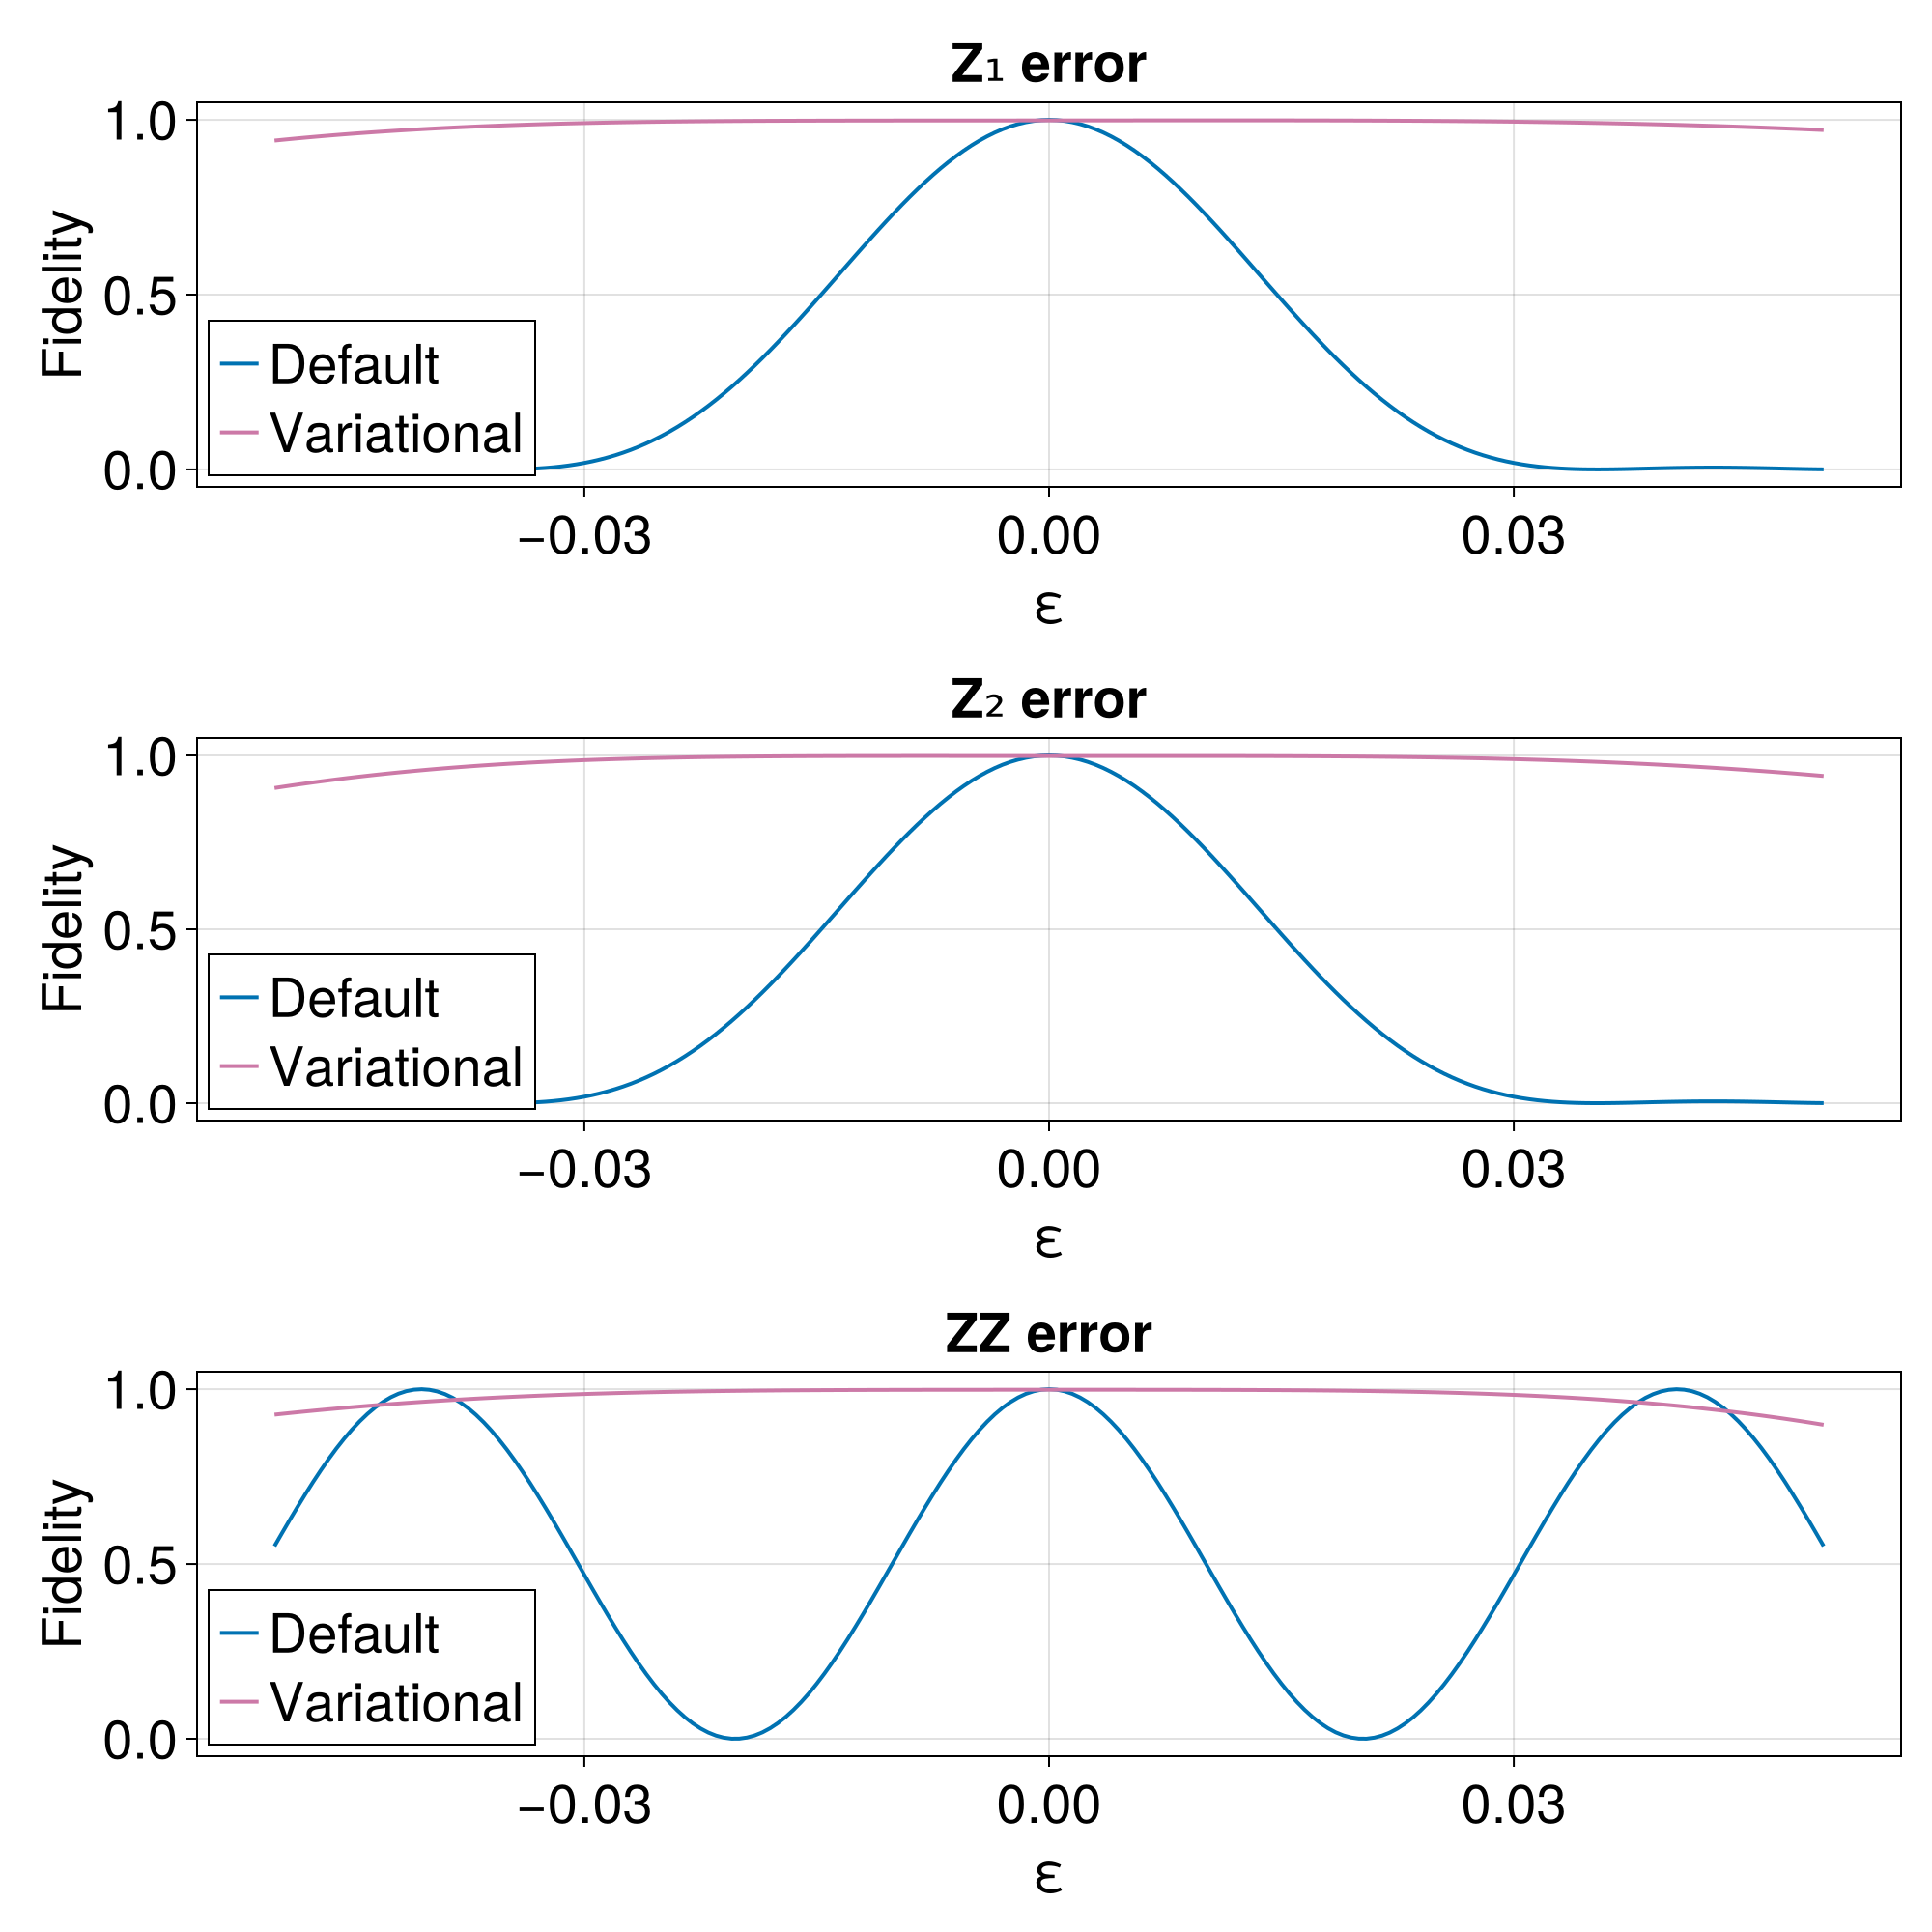

CairoMakie.Screen{IMAGE}


In [16]:
# %% Cell 2 — Fidelity curves vs Z1, Z2, ZZ error strength (TRAJ version)

# --- Build error operators using SAME basis as optimization (GATES.*) ---
Z1_err = GATES.Z ⊗ GATES.I
Z2_err = GATES.I ⊗ GATES.Z
ZZ_err = GATES.Z ⊗ GATES.Z

errors = [
    (Z1_err, "Z₁"),
    (Z2_err, "Z₂"),
    (ZZ_err, "ZZ"),
]

# IMPORTANT: now we store trajectories, not problems
problems = [
    (traj_def, "Default"),
    (traj_var, "Variational"),
    # (traj_uni, "Universal"),
]

εs = collect(-0.05:0.0005:0.05)

# Sweep: drift + ε*error, with the same controls
fidelity_curve(traj, H_err) = [
    unitary_rollout_fidelity(traj, QuantumSystem(H_drift + ε * H_err, H_drive))
    for ε in εs
]

colors = Makie.wong_colors()
colors = [colors[1], colors[4], colors[2]]  # adjust if you have 3 curves

f = Figure(fontsize=28, size=(1000, 1000))

for (row, (H_err, label_err)) in enumerate(errors)
    ax = Axis(f[row, 1],
        title  = "$label_err error",
        xlabel = "ε",
        ylabel = "Fidelity",
    )

    for (i, (traj, label_prob)) in enumerate(problems)
        ys = fidelity_curve(traj, H_err)
        lines!(ax, εs, ys; label=label_prob, color=colors[i], linewidth=2)
    end

    axislegend(ax; position=:lb)
end

display(f)

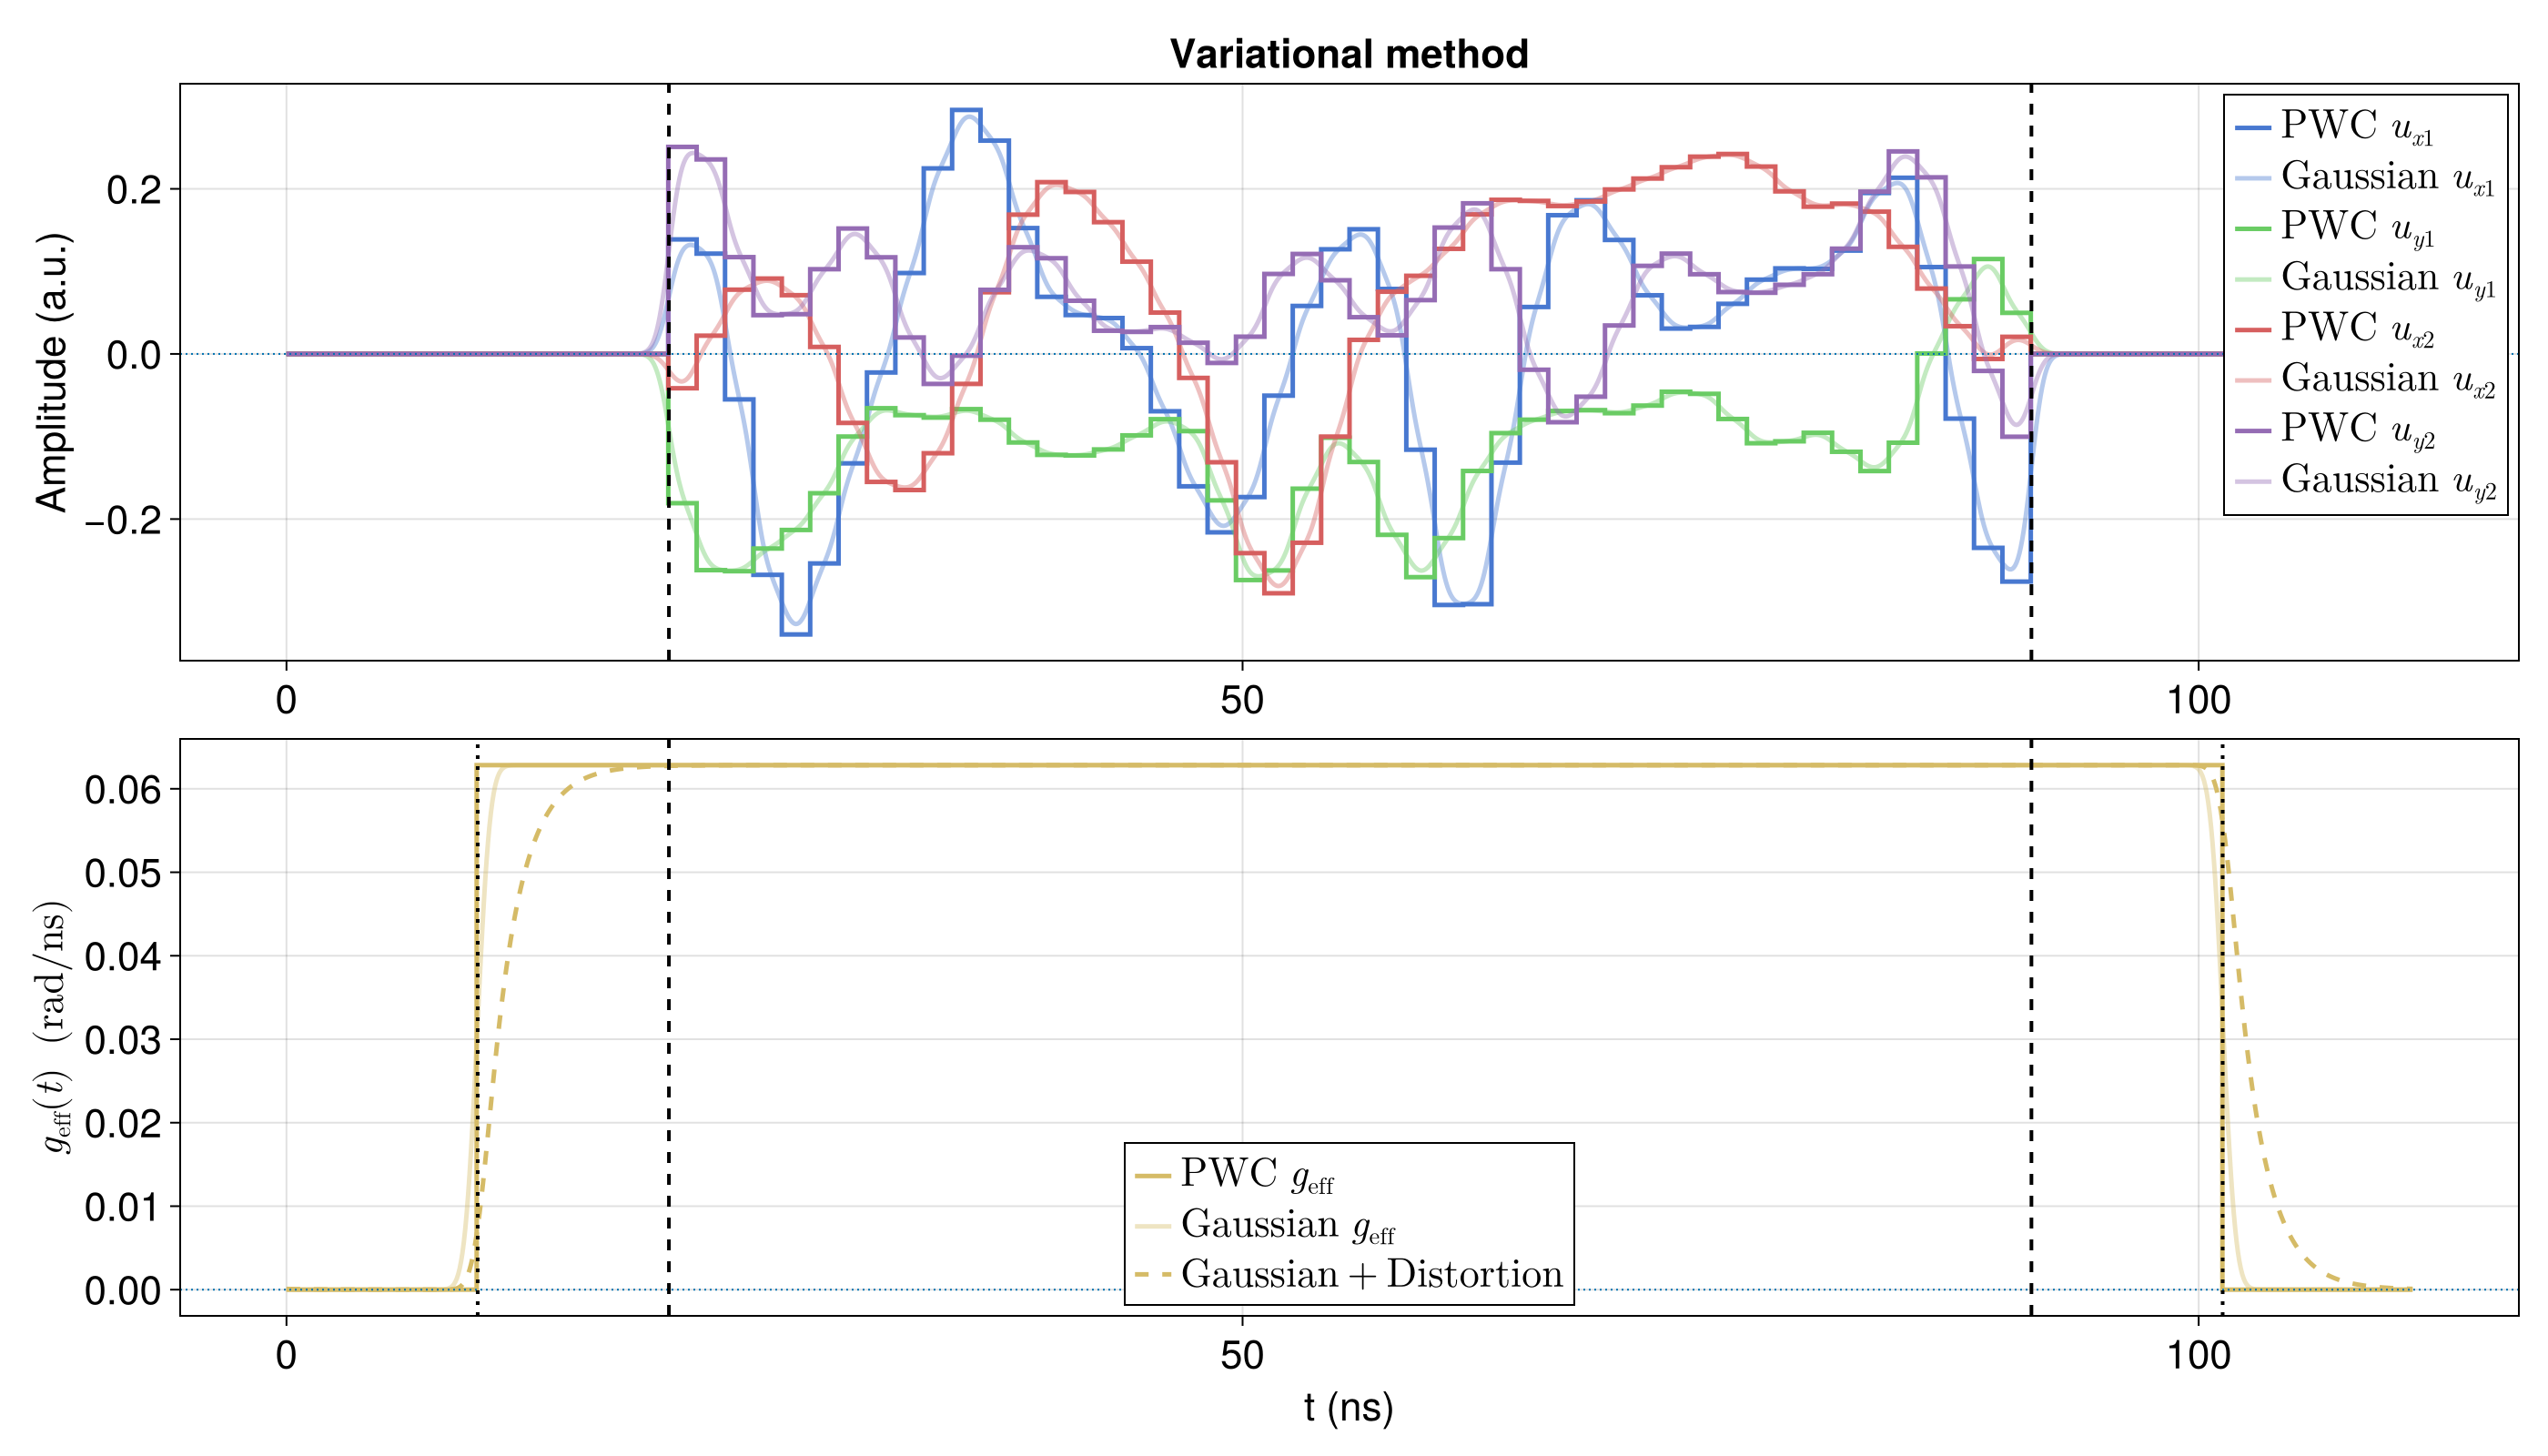

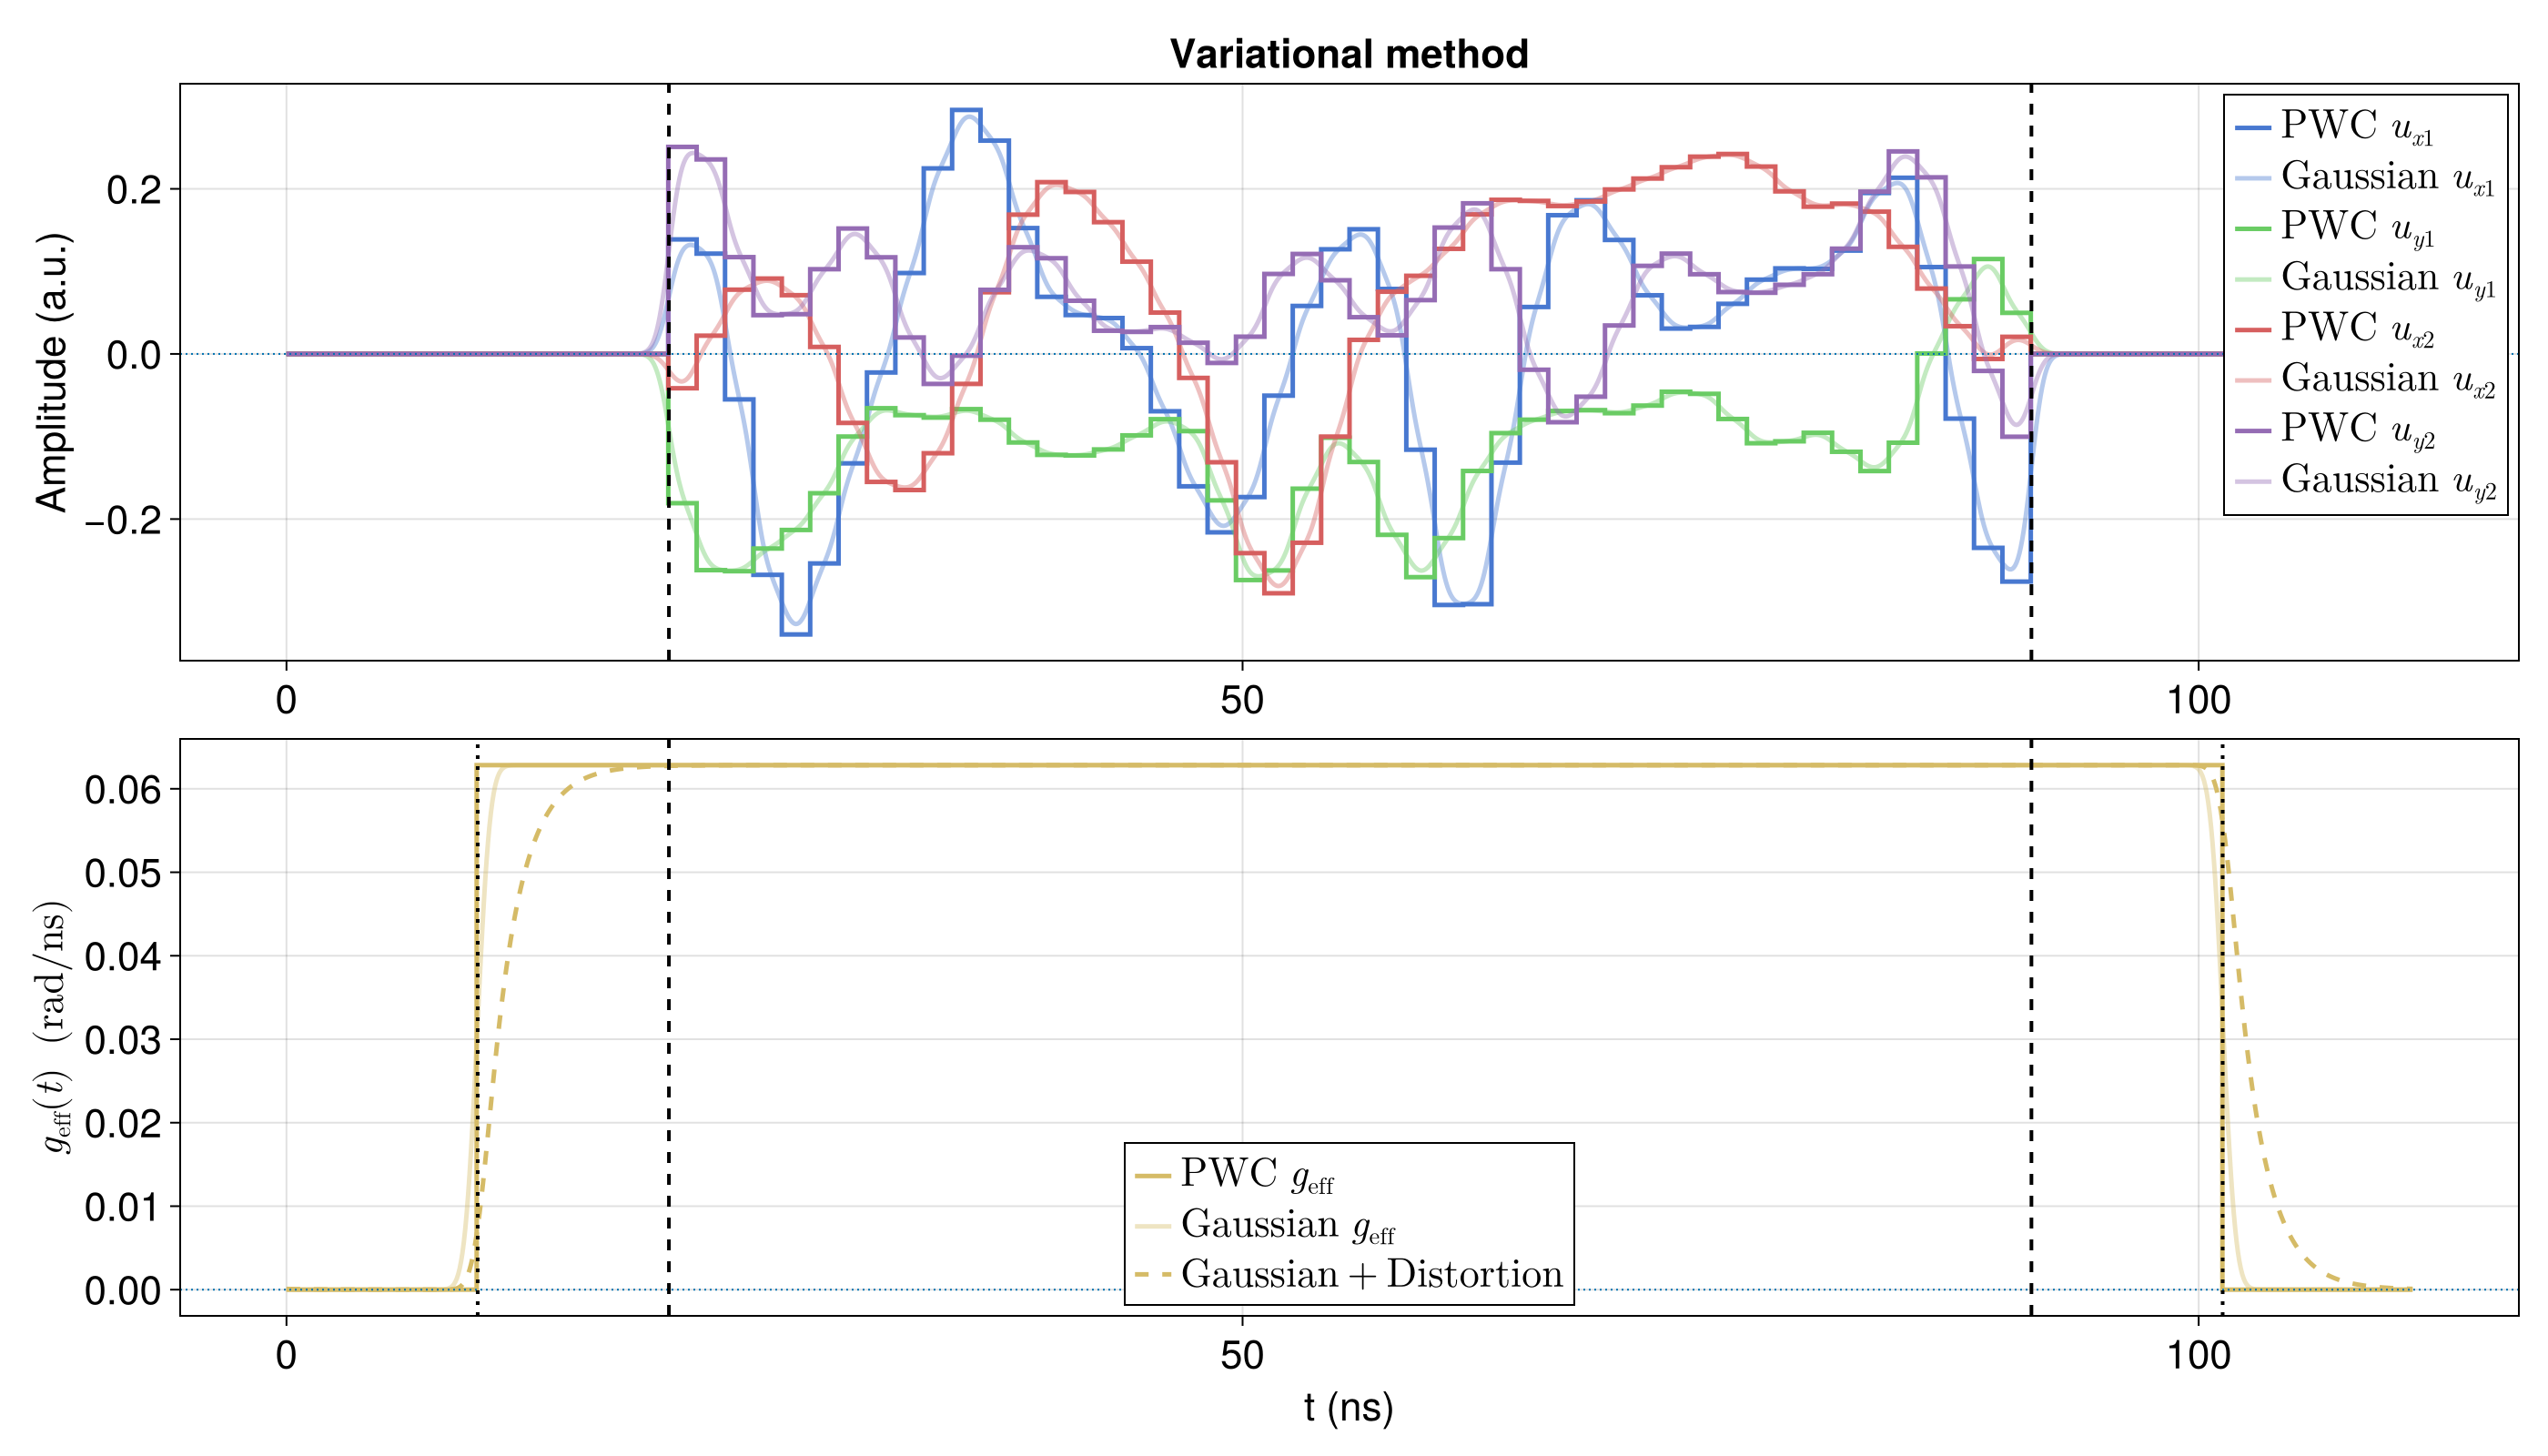

In [18]:
# %% Cell — self-contained plotting from ONLY traj_var / traj_def

using FFTW
using LinearAlgebra
using CairoMakie
using ColorSchemes
using MathTeXEngine

# ============================================================
# USER KNOBS
# ============================================================
off_before_ns = 10.0
geff_lead_ns  = 10.0
geff_trail_ns = 10.0
off_after_ns  = 10.0

g0 = 2π * 0.01

M = 20
B3dB_Hz = 250e6
on_tol = 1e-6

τr_ns = 1.5
Aexp  = 1.0

# ============================================================
# Helpers: pull controls + time nodes from traj robustly
# ============================================================
traj_get(traj, sym::Symbol) = try
    traj[sym]
catch
    getproperty(traj, sym)
end

function piccolo_A_as_Ndtx4(traj)
    A = traj_get(traj, :a)
    A = ndims(A) == 1 ? reshape(collect(A), :, 1) : Matrix(A)

    # if stored as 4×Ndt, transpose to Ndt×4
    if size(A, 1) == 4 && size(A, 2) > 4
        A = A'
    end

    @assert size(A, 2) ≥ 4 "Need ≥4 microwave controls in traj.a"
    return Matrix{Float64}(A[:, 1:4])  # Ndt×4
end

function time_nodes_ns(traj)
    dt = Float64.(vec(collect(traj_get(traj, :Δt))))
    return cumsum(vcat(0.0, dt))  # Ndt+1
end

function detect_microwave_window(A::AbstractMatrix{<:Real}, t_nodes::Vector{Float64}; on_tol=1e-6)
    Ndt = size(A, 1)
    active = falses(Ndt)
    @inbounds for k in 1:Ndt
        active[k] = maximum(abs.(A[k, 1:4])) > on_tol
    end
    any(active) || error("No microwave-on region detected (all |a| below tol=$on_tol).")

    i1 = findfirst(active)
    i2 = findlast(active)

    tμ_start = t_nodes[i1]
    tμ_end   = t_nodes[i2 + 1]
    return tμ_start, tμ_end
end

# ============================================================
# Build UNIFORM dt signals: OFF → geff lead → microwaves+geff → geff trail → OFF
# ============================================================
function build_pwc_with_geff_leadlag(traj;
    off_before_ns::Float64,
    geff_lead_ns::Float64,
    geff_trail_ns::Float64,
    off_after_ns::Float64,
    g0::Float64,
    M::Int,
    on_tol::Float64
)
    A = piccolo_A_as_Ndtx4(traj)
    t_nodes0 = time_nodes_ns(traj)

    tμ_start0, tμ_end0 = detect_microwave_window(A, t_nodes0; on_tol=on_tol)
    Tμ = tμ_end0 - tμ_start0

    # Shift Piccolo time so microwave start is at τ=0
    t_nodes_shift = t_nodes0 .- tμ_start0

    dt_min = minimum(diff(t_nodes0))
    dt = dt_min / M

    tμ_exp_start = off_before_ns + geff_lead_ns
    tμ_exp_end   = tμ_exp_start + Tμ

    g_start = off_before_ns
    g_end   = tμ_exp_end + geff_trail_ns

    T_end = g_end + off_after_ns
    t = collect(0.0:dt:T_end)

    function eval_interval(Acol::Vector{Float64}, τ::Float64)
        i = searchsortedlast(t_nodes_shift, τ)
        i = clamp(i, 1, length(Acol))
        return Acol[i]
    end

    a1 = Vector{Float64}(A[:, 1])
    a2 = Vector{Float64}(A[:, 2])
    a3 = Vector{Float64}(A[:, 3])
    a4 = Vector{Float64}(A[:, 4])

    ux1 = zeros(Float64, length(t))
    uy1 = zeros(Float64, length(t))
    ux2 = zeros(Float64, length(t))
    uy2 = zeros(Float64, length(t))
    geff = zeros(Float64, length(t))

    @inbounds for k in eachindex(t)
        tt = t[k]

        # microwaves ON only in [tμ_exp_start, tμ_exp_end)
        if (tt ≥ tμ_exp_start) && (tt < tμ_exp_end)
            τ = tt - tμ_exp_start
            ux1[k] = eval_interval(a1, τ)
            uy1[k] = eval_interval(a2, τ)
            ux2[k] = eval_interval(a3, τ)
            uy2[k] = eval_interval(a4, τ)
        end

        # g_eff ON in [g_start, g_end)
        if (tt ≥ g_start) && (tt < g_end)
            geff[k] = g0
        end
    end

    return (; t, dt, Tμ, tμ_exp_start, tμ_exp_end, g_start, g_end, ux1, uy1, ux2, uy2, geff)
end

# ============================================================
# Gaussian filter ALL 5 channels
# ============================================================
function fftfreq_hw(N::Int, dt_s::Float64)
    df = 1.0 / (N * dt_s)
    freqs = [k <= N ÷ 2 ? k : k - N for k in 0:N-1]
    return df .* freqs
end

function gaussian_response(freqs, B3dB::Float64)
    σf = B3dB / sqrt(log(2.0))
    @. exp(-0.5 * (freqs^2) / σf^2)
end

function gaussian_filter_all5(sig; B3dB_Hz::Float64)
    dt_s = sig.dt * 1e-9
    N = length(sig.t)

    freqs = fftfreq_hw(N, dt_s)
    G = gaussian_response(freqs, B3dB_Hz)

    filt(x) = real.(ifft(G .* fft(x)))

    return (; t = sig.t,
        ux1 = filt(sig.ux1),
        uy1 = filt(sig.uy1),
        ux2 = filt(sig.ux2),
        uy2 = filt(sig.uy2),
        geff = filt(sig.geff),
        freqs = freqs,
    )
end

# ============================================================
# Exp distortion AFTER Gaussian, ONLY on g_eff
# H(ω) = A / (1 + i ω τr)
# ============================================================
function exp_distort_from_freqs(u_in::Vector{Float64}, freqs_Hz::Vector{Float64};
    A::Float64 = 1.0,
    τr_ns::Float64 = 1.5,
    renorm::Symbol = :max
)
    τr_s = τr_ns * 1e-9
    ω = 2π .* freqs_Hz
    Hexp = @. A / (1 + 1im * ω * τr_s)

    u_out = real.(ifft(Hexp .* fft(u_in)))

    if renorm == :max
        mx_in  = maximum(abs.(u_in))
        mx_out = maximum(abs.(u_out))
        if mx_out > 0
            u_out .*= (mx_in / mx_out)
        end
    end

    return u_out
end

# ============================================================
# Your plot function (unchanged)
# ============================================================
cols = ColorSchemes.seaborn_muted6.colors
c1, c2, c3, c4, cG = cols[1], cols[2], cols[3], cols[4], cols[5]

function plot_mw_and_geff_2panel(sig_pwc, sig_gf, geff_gf_exp;
    title_str::AbstractString = "",
    alpha_filt::Float64 = 0.40,
    lw::Float64 = 2.5,
    fig_size = (1400, 800),
)
    t = sig_pwc.t
    vcol = :black

    fig = Figure(size=fig_size, fontsize=22)

    ax_mw = Axis(fig[1, 1],
        title  = title_str,
        ylabel = "Amplitude (a.u.)",
        xlabel = "",
    )

    stairs!(ax_mw, t, sig_pwc.ux1; color=c1, linewidth=lw, label=L"\mathrm{PWC}\;u_{x1}")
    lines!( ax_mw, t, sig_gf.ux1;  color=c1, linewidth=lw, alpha=alpha_filt, label=L"\mathrm{Gaussian}\;u_{x1}")

    stairs!(ax_mw, t, sig_pwc.uy1; color=c2, linewidth=lw, label=L"\mathrm{PWC}\;u_{y1}")
    lines!( ax_mw, t, sig_gf.uy1;  color=c2, linewidth=lw, alpha=alpha_filt, label=L"\mathrm{Gaussian}\;u_{y1}")

    stairs!(ax_mw, t, sig_pwc.ux2; color=c3, linewidth=lw, label=L"\mathrm{PWC}\;u_{x2}")
    lines!( ax_mw, t, sig_gf.ux2;  color=c3, linewidth=lw, alpha=alpha_filt, label=L"\mathrm{Gaussian}\;u_{x2}")

    stairs!(ax_mw, t, sig_pwc.uy2; color=c4, linewidth=lw, label=L"\mathrm{PWC}\;u_{y2}")
    lines!( ax_mw, t, sig_gf.uy2;  color=c4, linewidth=lw, alpha=alpha_filt, label=L"\mathrm{Gaussian}\;u_{y2}")

    hlines!(ax_mw, [0.0], linestyle=:dot, linewidth=1)

    vlines!(ax_mw, [sig_pwc.tμ_exp_start]; color=vcol, linestyle=:dash, linewidth=2)
    vlines!(ax_mw, [sig_pwc.tμ_exp_end];   color=vcol, linestyle=:dash, linewidth=2)

    axislegend(ax_mw, position=:rt, framevisible=true)

    ax_g = Axis(fig[2, 1],
        ylabel = L"g_{\mathrm{eff}}(t)\;\;(\mathrm{rad/ns})",
        xlabel = "t (ns)",
    )

    stairs!(ax_g, t, sig_pwc.geff; color=cG, linewidth=lw, label=L"\mathrm{PWC}\;g_{\mathrm{eff}}")
    lines!( ax_g, t, sig_gf.geff;  color=cG, linewidth=lw, alpha=alpha_filt, label=L"\mathrm{Gaussian}\;g_{\mathrm{eff}}")
    lines!( ax_g, t, geff_gf_exp;  color=cG, linewidth=lw, linestyle=:dash, label=L"\mathrm{Gaussian} + \mathrm{Distortion}")

    hlines!(ax_g, [0.0], linestyle=:dot, linewidth=1)

    vlines!(ax_g, [sig_pwc.g_start];      color=vcol, linestyle=:dot,  linewidth=2)
    vlines!(ax_g, [sig_pwc.tμ_exp_start]; color=vcol, linestyle=:dash, linewidth=2)
    vlines!(ax_g, [sig_pwc.tμ_exp_end];   color=vcol, linestyle=:dash, linewidth=2)
    vlines!(ax_g, [sig_pwc.g_end];        color=vcol, linestyle=:dot,  linewidth=2)

    axislegend(ax_g, position=:cb, framevisible=true)

    rowgap!(fig.layout, 10)
    colgap!(fig.layout, 10)

    display(fig)
    return fig
end

# ============================================================
# RUN (requires traj_var exists)
# ============================================================
@assert @isdefined(traj_var) "traj_var not defined. Load it first: @load \"traj_var.jld2\" traj_var"

sig_var = build_pwc_with_geff_leadlag(traj_var;
    off_before_ns=off_before_ns,
    geff_lead_ns=geff_lead_ns,
    geff_trail_ns=geff_trail_ns,
    off_after_ns=off_after_ns,
    g0=g0,
    M=M,
    on_tol=on_tol
)

gf_var = gaussian_filter_all5(sig_var; B3dB_Hz=B3dB_Hz)

geff_var_gf_exp = exp_distort_from_freqs(Vector{Float64}(gf_var.geff), Vector{Float64}(gf_var.freqs);
    A=Aexp, τr_ns=τr_ns, renorm=:max
)

plot_mw_and_geff_2panel(sig_var, gf_var, geff_var_gf_exp; title_str="Variational method")


===== GAUSSIAN (ALL 5) log-infidelity =====

===== GAUSSIAN → EXP (g_eff only) log-infidelity =====

DONE (traj-only log-infidelity heatmaps).


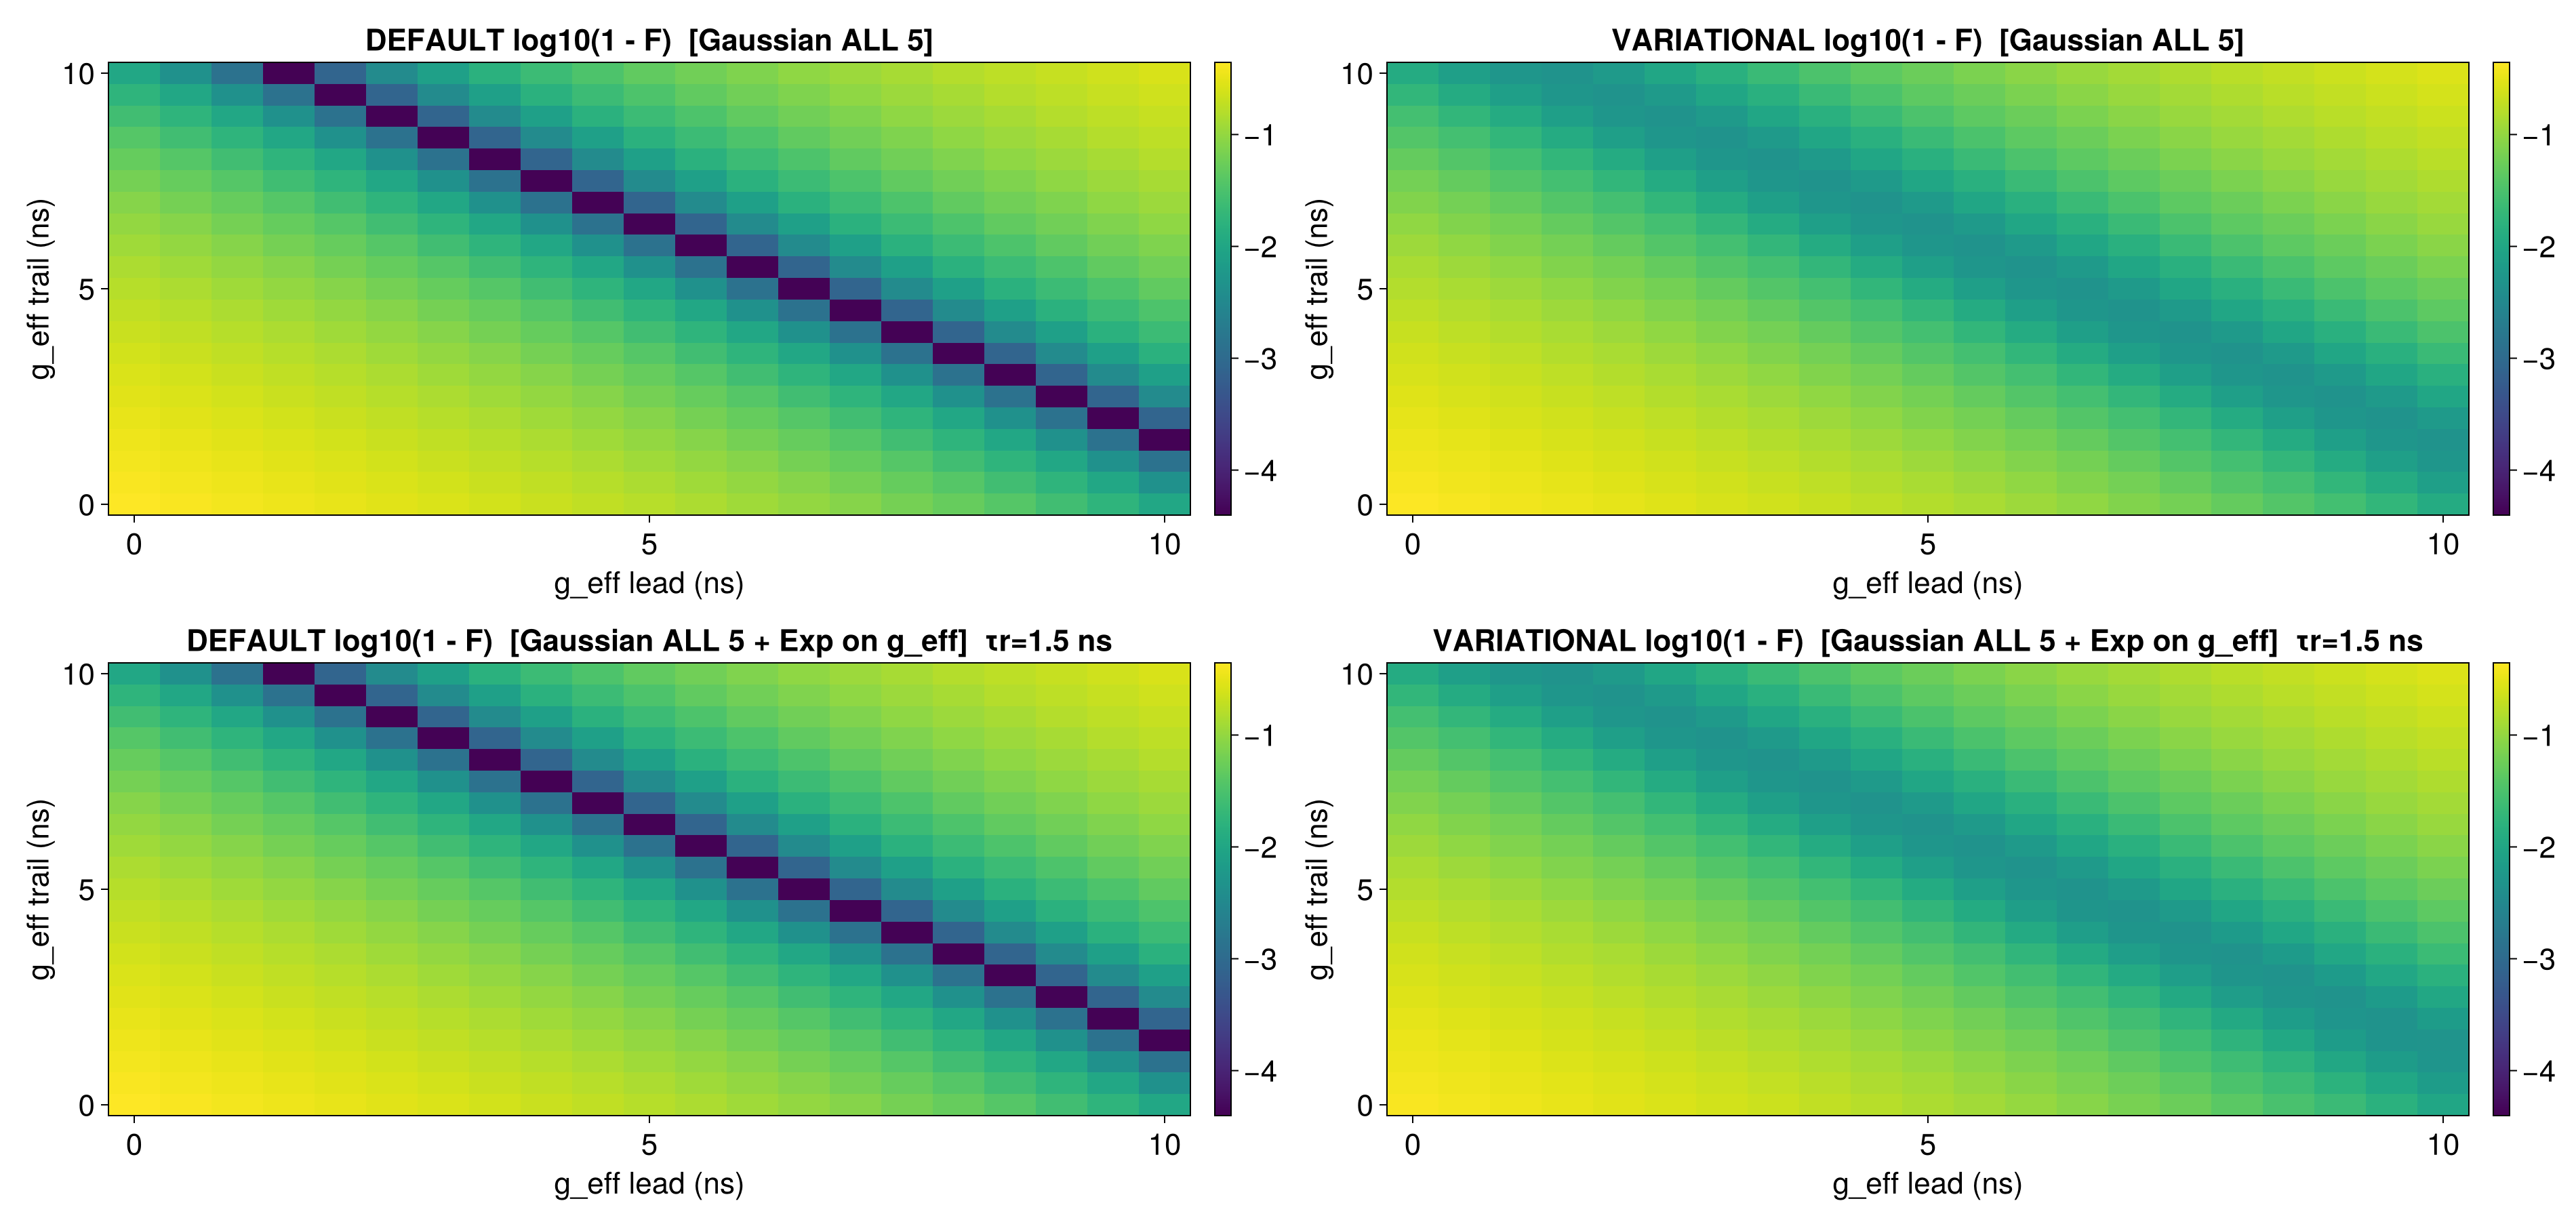

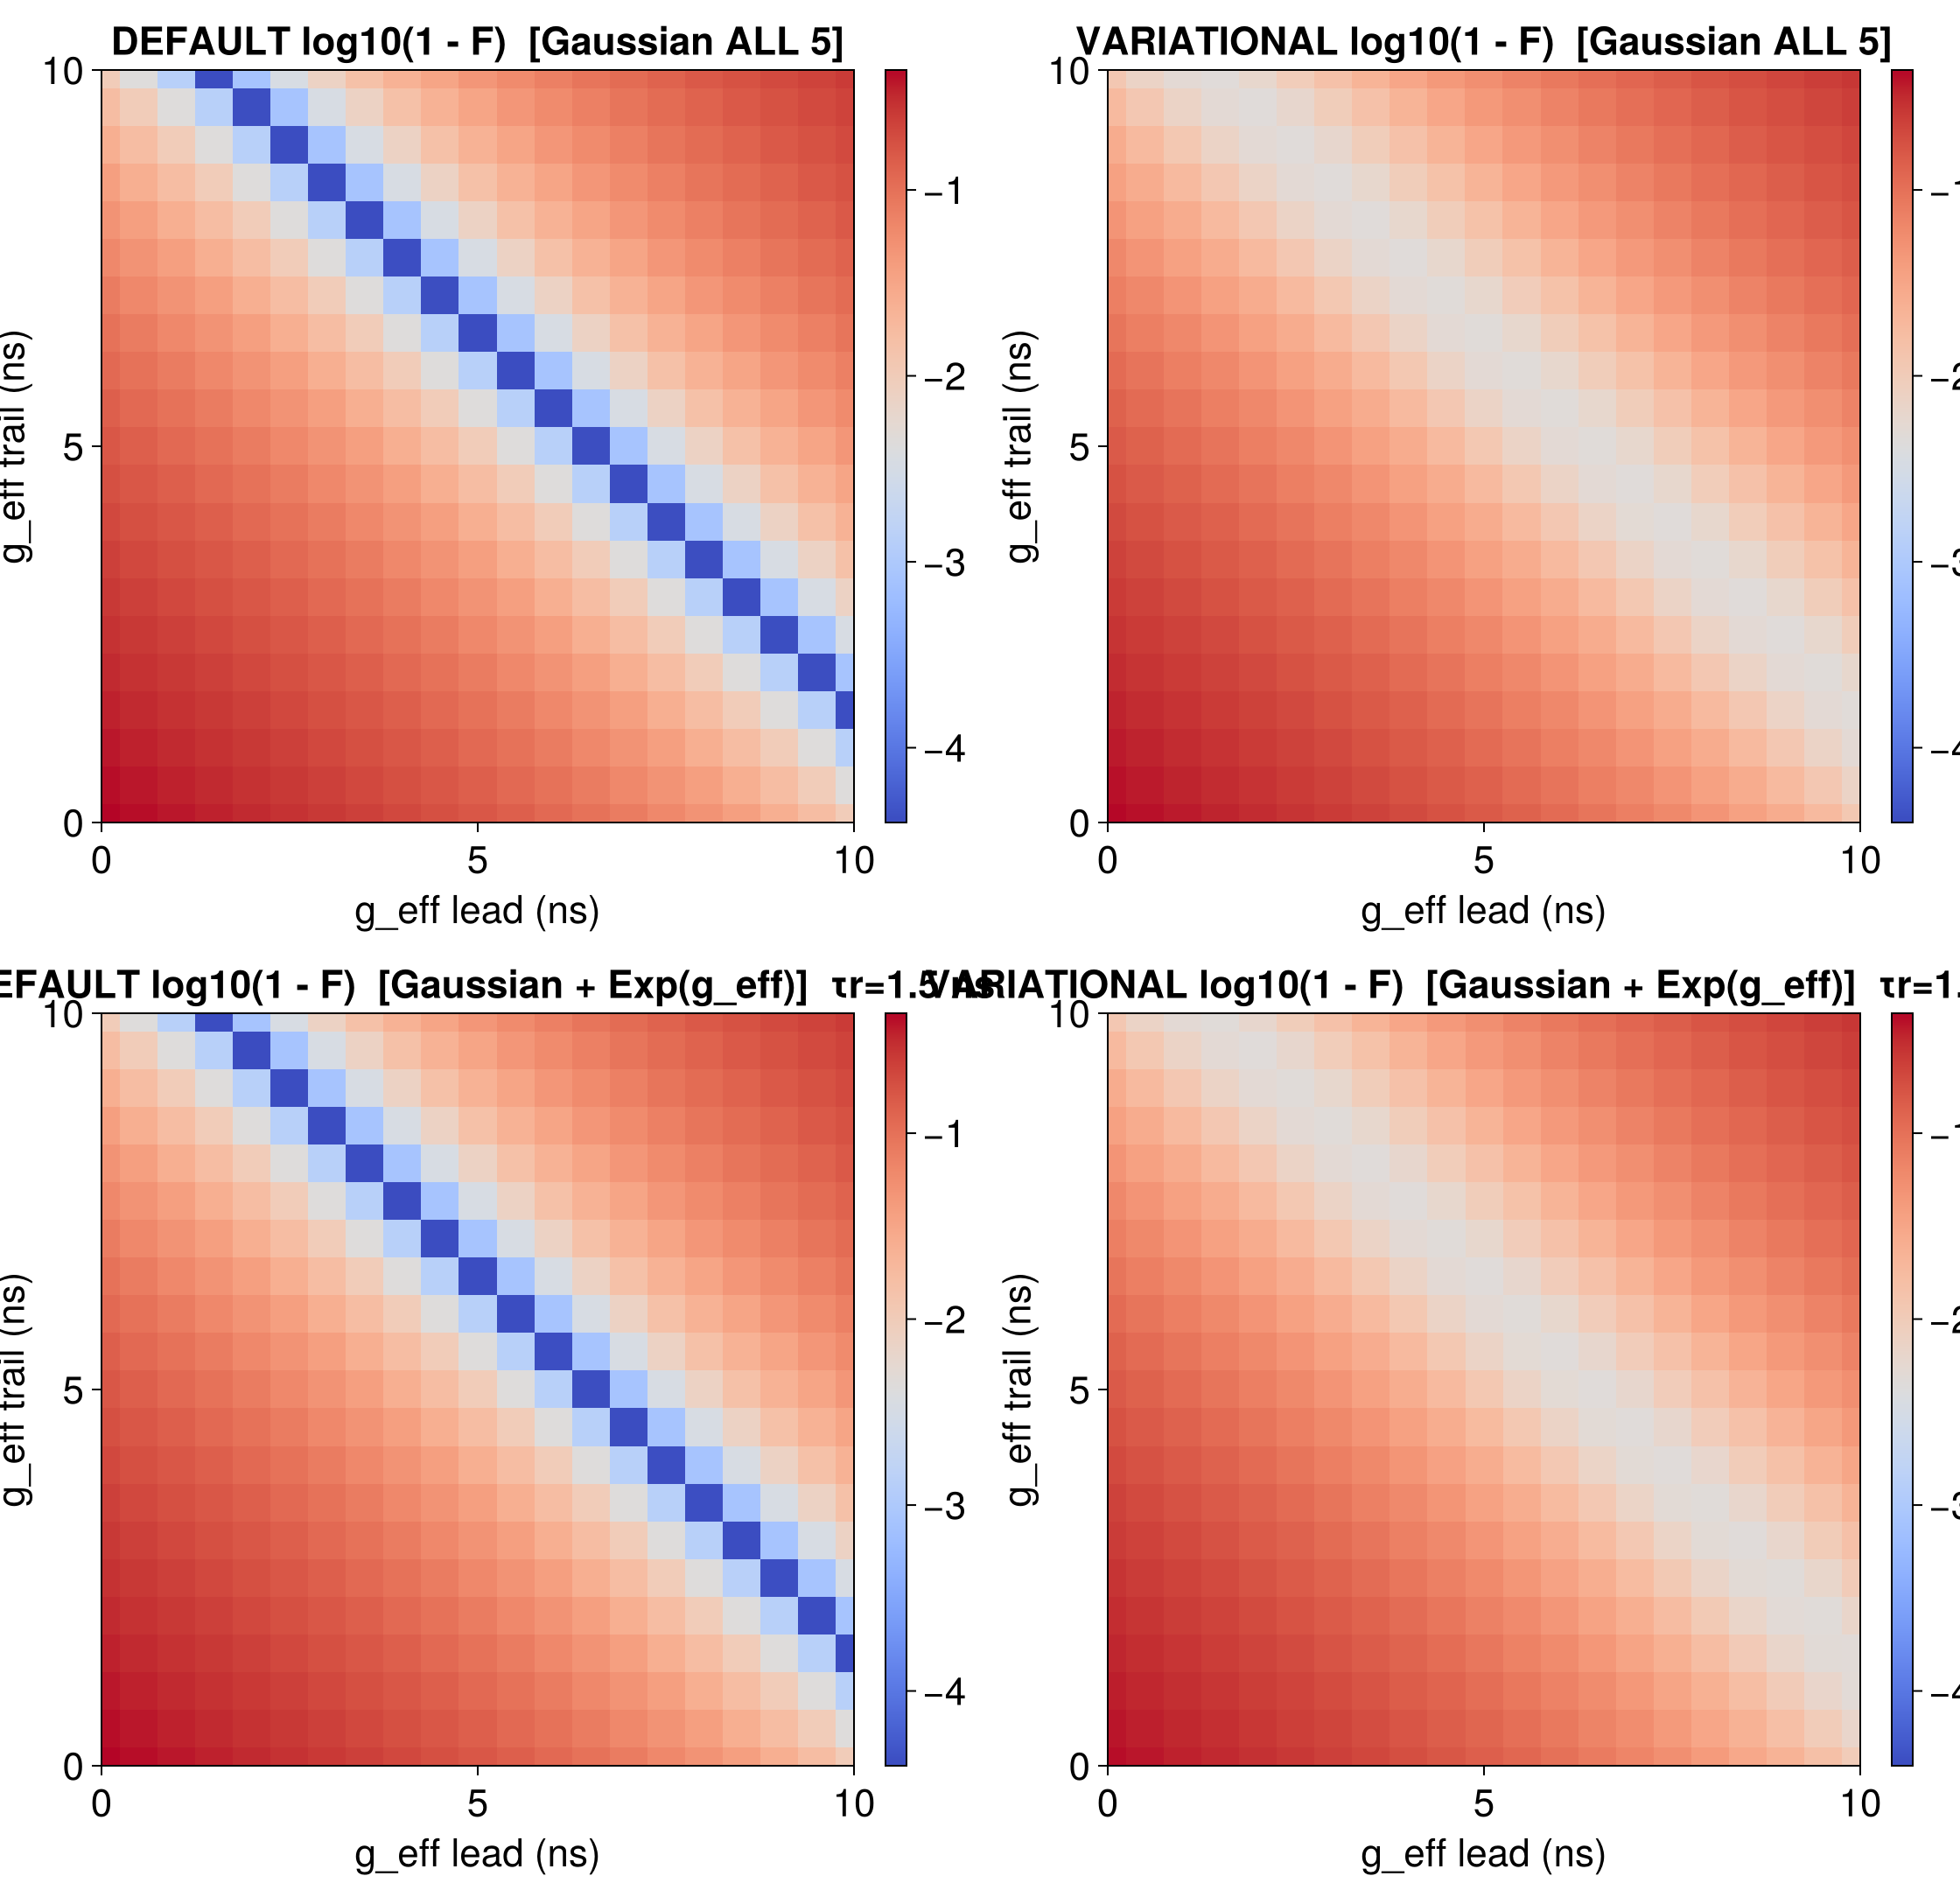

In [19]:
# %% Cell — lead/trail log-infidelity heatmaps (traj_def / traj_var ONLY)

using FFTW
using LinearAlgebra
using QuantumToolbox
using CairoMakie
using Base.Threads

const QT = QuantumToolbox

# ============================================================
# REQUIRE: you already loaded these trajectories
#   @load "traj_def.jld2" traj_def
#   @load "traj_var.jld2" traj_var
# ============================================================
@assert @isdefined(traj_def) "traj_def not defined. Run: @load \"traj_def.jld2\" traj_def"
@assert @isdefined(traj_var) "traj_var not defined. Run: @load \"traj_var.jld2\" traj_var"

# ============================================================
# USER SETTINGS
# ============================================================
OFF_BEFORE_NS = 10.0
OFF_AFTER_NS  = 10.0

G0 = 2π * 0.01           # rad/ns
ON_TOL = 1e-6

UPSAMPLE_M = 20
B3DB_GHZ   = 0.25        # 250 MHz = 0.25 GHz

# REQUIRED: filtering must be ON for exp distortion
USE_FILTER = true

LEAD_VALS  = collect(0.0:0.5:10.0)
TRAIL_VALS = collect(0.0:0.5:10.0)

TAU_R_NS = 1.5
A_EXP    = 1.0
RENORM   = :max

EPS_INF  = 1e-16

# ============================================================
# 0) 2-Qubit operators + iSWAP target
# ============================================================
sx = QT.sigmax()
sy = QT.sigmay()
I2 = QT.qeye(2)

X1 = QT.tensor(sx, I2)
Y1 = QT.tensor(sy, I2)
X2 = QT.tensor(I2, sx)
Y2 = QT.tensor(I2, sy)

XX = QT.tensor(sx, sx)
YY = QT.tensor(sy, sy)

U_iswap_qt  = exp(1.0im * π/4 * (XX + YY))
U_iswap_mat = Matrix(U_iswap_qt.data)

gate_fidelity(U::AbstractMatrix{ComplexF64}, Ugoal::AbstractMatrix{ComplexF64}) =
    abs(tr(Ugoal' * U)) / size(U, 1)

# ============================================================
# 1) Piccolo trajectory getters
# ============================================================
traj_get(traj, sym::Symbol) = try traj[sym] catch; getproperty(traj, sym) end

function piccolo_A_as_Ndtx4(traj)
    A = traj_get(traj, :a)
    A = ndims(A) == 1 ? reshape(collect(A), :, 1) : Matrix(A)

    if size(A, 1) == 4 && size(A, 2) > 4
        A = A'
    end
    @assert size(A, 2) ≥ 4 "Need ≥4 microwave controls in traj.a"
    return Matrix{Float64}(A[:, 1:4])
end

function time_nodes_ns(traj)
    dt = Float64.(vec(collect(traj_get(traj, :Δt))))
    return cumsum(vcat(0.0, dt))
end

function detect_microwave_window(A::AbstractMatrix{<:Real}, t_nodes::Vector{Float64}; on_tol=1e-6)
    Ndt = size(A, 1)
    active = falses(Ndt)
    @inbounds for k in 1:Ndt
        active[k] = maximum(abs.(A[k, 1:4])) > on_tol
    end
    any(active) || error("No microwave-on region detected (all |a| below tol=$on_tol).")

    i1 = findfirst(active)
    i2 = findlast(active)
    return t_nodes[i1], t_nodes[i2 + 1]
end

# ============================================================
# 2) FFT helpers in ns/GHz
# ============================================================
function fftfreq_GHz(N::Int, dt_ns::Float64)
    df = 1.0 / (N * dt_ns)  # 1/ns = GHz
    freqs = [k <= N ÷ 2 ? k : k - N for k in 0:N-1]
    return df .* freqs
end

function gaussian_response_GHz(freqs_GHz::AbstractVector{<:Real}, B3dB_GHz::Float64)
    σf = B3dB_GHz / sqrt(log(2.0))
    @. exp(-0.5 * (freqs_GHz^2) / σf^2)
end

function gaussian_filter_all5_GHz(
    t_ns::AbstractVector{<:Real},
    ux1::AbstractVector{<:Real}, uy1::AbstractVector{<:Real},
    ux2::AbstractVector{<:Real}, uy2::AbstractVector{<:Real},
    geff::AbstractVector{<:Real};
    B3dB_GHz::Float64 = 0.25
)
    t  = Vector{Float64}(collect(t_ns))
    x1 = Vector{Float64}(collect(ux1))
    y1 = Vector{Float64}(collect(uy1))
    x2 = Vector{Float64}(collect(ux2))
    y2 = Vector{Float64}(collect(uy2))
    g  = Vector{Float64}(collect(geff))

    dt_ns = t[2] - t[1]
    N = length(t)

    freqs = fftfreq_GHz(N, dt_ns)
    G = gaussian_response_GHz(freqs, B3dB_GHz)

    filt(v) = real.(ifft(G .* fft(v)))

    return filt(x1), filt(y1), filt(x2), filt(y2), filt(g), freqs
end

function exp_distort_geff_after_gaussian(
    geff_gf::Vector{Float64},
    freqs_GHz::Vector{Float64};
    τr_ns::Float64 = 1.5,
    A::Float64 = 1.0,
    renorm::Symbol = :max
)
    f = freqs_GHz
    ω = 2π .* f  # rad/ns

    Hexp = @. A / (1 + 1im * ω * τr_ns)
    g_out = real.(ifft(Hexp .* fft(geff_gf)))

    if renorm == :max
        mx_in  = maximum(abs.(geff_gf))
        mx_out = maximum(abs.(g_out))
        if mx_out > 0
            g_out .*= (mx_in / mx_out)
        end
    elseif renorm == :area
        area_in  = sum(geff_gf)
        area_out = sum(g_out)
        if abs(area_out) > 0
            g_out .*= (area_in / area_out)
        end
    end

    return g_out
end

# ============================================================
# 3) Build PWC signals: OFF → geff lead → microwaves+geff → geff trail → OFF
# ============================================================
function build_signals_leadtrail(traj;
    off_before_ns::Float64,
    off_after_ns::Float64,
    geff_lead_ns::Float64,
    geff_trail_ns::Float64,
    g0::Float64,
    upsample_M::Int,
    on_tol::Float64
)
    A = piccolo_A_as_Ndtx4(traj)
    t_nodes0 = time_nodes_ns(traj)

    tμ_start0, tμ_end0 = detect_microwave_window(A, t_nodes0; on_tol=on_tol)
    Tμ = tμ_end0 - tμ_start0

    t_nodes_shift = t_nodes0 .- tμ_start0

    dt_min = minimum(diff(t_nodes0))
    dt = dt_min / upsample_M

    tμ_exp_start = off_before_ns + geff_lead_ns
    tμ_exp_end   = tμ_exp_start + Tμ

    g_start = off_before_ns
    g_end   = tμ_exp_end + geff_trail_ns
    T_end   = g_end + off_after_ns

    N = Int(ceil(T_end / dt)) + 1
    t = Vector{Float64}((0:N-1) .* dt)

    function eval_interval(Acol::Vector{Float64}, τ::Float64)
        i = searchsortedlast(t_nodes_shift, τ)
        i = clamp(i, 1, length(Acol))
        return Acol[i]
    end

    a1 = Vector{Float64}(A[:, 1])
    a2 = Vector{Float64}(A[:, 2])
    a3 = Vector{Float64}(A[:, 3])
    a4 = Vector{Float64}(A[:, 4])

    ux1 = zeros(Float64, length(t))
    uy1 = zeros(Float64, length(t))
    ux2 = zeros(Float64, length(t))
    uy2 = zeros(Float64, length(t))
    geff = zeros(Float64, length(t))

    @inbounds for k in eachindex(t)
        tt = t[k]

        if (tt ≥ tμ_exp_start) && (tt < tμ_exp_end)
            τ = tt - tμ_exp_start
            ux1[k] = eval_interval(a1, τ)
            uy1[k] = eval_interval(a2, τ)
            ux2[k] = eval_interval(a3, τ)
            uy2[k] = eval_interval(a4, τ)
        end

        if (tt ≥ g_start) && (tt < g_end)
            geff[k] = g0
        end
    end

    return (; t, ux1, uy1, ux2, uy2, geff)
end

# ============================================================
# 4) Simulate unitary from arrays
# ============================================================
function simulate_unitary_2q(
    t_ns::Vector{Float64},
    ux1::Vector{Float64}, uy1::Vector{Float64},
    ux2::Vector{Float64}, uy2::Vector{Float64},
    geff::Vector{Float64}
)
    N = length(t_ns)
    dt = t_ns[2] - t_ns[1]

    function coef_from(arr::Vector{Float64})
        function c(p, tt)
            idx = Int(floor(tt / dt)) + 1
            return arr[clamp(idx, 1, length(arr))]
        end
        return c
    end

    H_t = QT.QobjEvo((
        ((XX + YY), coef_from(geff)),
        (X1, coef_from(ux1)),
        (Y1, coef_from(uy1)),
        (X2, coef_from(ux2)),
        (Y2, coef_from(uy2)),
    ))

    basis2(i) = QT.basis(2, i)
    kets = [
        QT.tensor(basis2(0), basis2(0)),
        QT.tensor(basis2(0), basis2(1)),
        QT.tensor(basis2(1), basis2(0)),
        QT.tensor(basis2(1), basis2(1)),
    ]

    U = zeros(ComplexF64, 4, 4)
    for j in 1:4
        sol = QT.sesolve(H_t, kets[j], t_ns; progress_bar = Val(false))
        ψT = sol.states[end]
        U[:, j] .= vec(Array(ψT.data))
    end

    return U
end

# ============================================================
# 5) Heatmap sweep (log10(1-F))
# ============================================================
function leadtrail_loginf_heatmap(traj, lead_vals, trail_vals;
    mode::Symbol,
    off_before_ns::Float64,
    off_after_ns::Float64,
    g0::Float64,
    upsample_M::Int,
    on_tol::Float64,
    use_filter::Bool,
    B3dB_GHz::Float64,
    τr_ns::Float64,
    Aexp::Float64,
    renorm::Symbol,
    eps_inf::Float64
)
    if mode == :gaussian_plus_exp && !use_filter
        error("Requested :gaussian_plus_exp but USE_FILTER=false.")
    end
    if mode == :gaussian && !use_filter
        error("Requested :gaussian but USE_FILTER=false.")
    end

    nL = length(lead_vals)
    nT = length(trail_vals)
    LogI = Matrix{Float64}(undef, nT, nL)  # [trail, lead]

    @threads for j in 1:nL
        lead = lead_vals[j]
        for i in 1:nT
            trail = trail_vals[i]

            sig = build_signals_leadtrail(traj;
                off_before_ns=off_before_ns,
                off_after_ns=off_after_ns,
                geff_lead_ns=lead,
                geff_trail_ns=trail,
                g0=g0,
                upsample_M=upsample_M,
                on_tol=on_tol
            )

            ux1_gf, uy1_gf, ux2_gf, uy2_gf, geff_gf, freqs =
                gaussian_filter_all5_GHz(sig.t, sig.ux1, sig.uy1, sig.ux2, sig.uy2, sig.geff; B3dB_GHz=B3dB_GHz)

            geff_final = mode == :gaussian_plus_exp ?
                exp_distort_geff_after_gaussian(geff_gf, freqs; τr_ns=τr_ns, A=Aexp, renorm=renorm) :
                geff_gf

            U = simulate_unitary_2q(sig.t, ux1_gf, uy1_gf, ux2_gf, uy2_gf, geff_final)
            F = gate_fidelity(U, U_iswap_mat)

            LogI[i, j] = log10(clamp(1 - F, eps_inf, 1.0))
        end
    end

    return LogI
end

# ============================================================
# 6) RUN BOTH MODES for BOTH trajectories
# ============================================================
println("\n===== GAUSSIAN (ALL 5) log-infidelity =====")
LogI_def_g = leadtrail_loginf_heatmap(traj_def, LEAD_VALS, TRAIL_VALS;
    mode=:gaussian,
    off_before_ns=OFF_BEFORE_NS, off_after_ns=OFF_AFTER_NS,
    g0=G0, upsample_M=UPSAMPLE_M, on_tol=ON_TOL,
    use_filter=USE_FILTER, B3dB_GHz=B3DB_GHZ,
    τr_ns=TAU_R_NS, Aexp=A_EXP, renorm=RENORM,
    eps_inf=EPS_INF
)

LogI_var_g = leadtrail_loginf_heatmap(traj_var, LEAD_VALS, TRAIL_VALS;
    mode=:gaussian,
    off_before_ns=OFF_BEFORE_NS, off_after_ns=OFF_AFTER_NS,
    g0=G0, upsample_M=UPSAMPLE_M, on_tol=ON_TOL,
    use_filter=USE_FILTER, B3dB_GHz=B3DB_GHZ,
    τr_ns=TAU_R_NS, Aexp=A_EXP, renorm=RENORM,
    eps_inf=EPS_INF
)

println("\n===== GAUSSIAN → EXP (g_eff only) log-infidelity =====")
LogI_def_ge = leadtrail_loginf_heatmap(traj_def, LEAD_VALS, TRAIL_VALS;
    mode=:gaussian_plus_exp,
    off_before_ns=OFF_BEFORE_NS, off_after_ns=OFF_AFTER_NS,
    g0=G0, upsample_M=UPSAMPLE_M, on_tol=ON_TOL,
    use_filter=USE_FILTER, B3dB_GHz=B3DB_GHZ,
    τr_ns=TAU_R_NS, Aexp=A_EXP, renorm=RENORM,
    eps_inf=EPS_INF
)

LogI_var_ge = leadtrail_loginf_heatmap(traj_var, LEAD_VALS, TRAIL_VALS;
    mode=:gaussian_plus_exp,
    off_before_ns=OFF_BEFORE_NS, off_after_ns=OFF_AFTER_NS,
    g0=G0, upsample_M=UPSAMPLE_M, on_tol=ON_TOL,
    use_filter=USE_FILTER, B3dB_GHz=B3DB_GHZ,
    τr_ns=TAU_R_NS, Aexp=A_EXP, renorm=RENORM,
    eps_inf=EPS_INF
)

# ============================================================
# 7) PLOT FIGURE 1 (big 2×2)
# ============================================================
all_vals = vcat(vec(LogI_def_g), vec(LogI_var_g), vec(LogI_def_ge), vec(LogI_var_ge))
clims = (minimum(all_vals), maximum(all_vals))

fig_big = Figure(size=(1900, 900), fontsize=22)

ax11 = Axis(fig_big[1, 1], xlabel="g_eff lead (ns)", ylabel="g_eff trail (ns)",
    title="DEFAULT log10(1 - F)  [Gaussian ALL 5]"
)
hm11 = heatmap!(ax11, LEAD_VALS, TRAIL_VALS, LogI_def_g; colorrange=clims)
Colorbar(fig_big[1, 2], hm11)

ax12 = Axis(fig_big[1, 3], xlabel="g_eff lead (ns)", ylabel="g_eff trail (ns)",
    title="VARIATIONAL log10(1 - F)  [Gaussian ALL 5]"
)
hm12 = heatmap!(ax12, LEAD_VALS, TRAIL_VALS, LogI_var_g; colorrange=clims)
Colorbar(fig_big[1, 4], hm12)

ax21 = Axis(fig_big[2, 1], xlabel="g_eff lead (ns)", ylabel="g_eff trail (ns)",
    title="DEFAULT log10(1 - F)  [Gaussian ALL 5 + Exp on g_eff]  τr=$(TAU_R_NS) ns"
)
hm21 = heatmap!(ax21, LEAD_VALS, TRAIL_VALS, LogI_def_ge; colorrange=clims)
Colorbar(fig_big[2, 2], hm21)

ax22 = Axis(fig_big[2, 3], xlabel="g_eff lead (ns)", ylabel="g_eff trail (ns)",
    title="VARIATIONAL log10(1 - F)  [Gaussian ALL 5 + Exp on g_eff]  τr=$(TAU_R_NS) ns"
)
hm22 = heatmap!(ax22, LEAD_VALS, TRAIL_VALS, LogI_var_ge; colorrange=clims)
Colorbar(fig_big[2, 4], hm22)

display(fig_big)

# ============================================================
# 8) PLOT FIGURE 2 (square panels + hot/cold)
# ============================================================
CMAP = :coolwarm
AX = 430

xlo, xhi = extrema(LEAD_VALS)
ylo, yhi = extrema(TRAIL_VALS)

fig_sq = Figure(size=(2AX + 260, 2AX + 220), fontsize=22)

ax11 = Axis(fig_sq[1, 1], xlabel="g_eff lead (ns)", ylabel="g_eff trail (ns)",
    title="DEFAULT log10(1 - F)  [Gaussian ALL 5]", width=AX, height=AX
)
hm11 = heatmap!(ax11, LEAD_VALS, TRAIL_VALS, LogI_def_g; colormap=CMAP, colorrange=clims)
xlims!(ax11, xlo, xhi); ylims!(ax11, ylo, yhi)
Colorbar(fig_sq[1, 2], hm11)

ax12 = Axis(fig_sq[1, 3], xlabel="g_eff lead (ns)", ylabel="g_eff trail (ns)",
    title="VARIATIONAL log10(1 - F)  [Gaussian ALL 5]", width=AX, height=AX
)
hm12 = heatmap!(ax12, LEAD_VALS, TRAIL_VALS, LogI_var_g; colormap=CMAP, colorrange=clims)
xlims!(ax12, xlo, xhi); ylims!(ax12, ylo, yhi)
Colorbar(fig_sq[1, 4], hm12)

ax21 = Axis(fig_sq[2, 1], xlabel="g_eff lead (ns)", ylabel="g_eff trail (ns)",
    title="DEFAULT log10(1 - F)  [Gaussian + Exp(g_eff)]  τr=$(TAU_R_NS) ns", width=AX, height=AX
)
hm21 = heatmap!(ax21, LEAD_VALS, TRAIL_VALS, LogI_def_ge; colormap=CMAP, colorrange=clims)
xlims!(ax21, xlo, xhi); ylims!(ax21, ylo, yhi)
Colorbar(fig_sq[2, 2], hm21)

ax22 = Axis(fig_sq[2, 3], xlabel="g_eff lead (ns)", ylabel="g_eff trail (ns)",
    title="VARIATIONAL log10(1 - F)  [Gaussian + Exp(g_eff)]  τr=$(TAU_R_NS) ns", width=AX, height=AX
)
hm22 = heatmap!(ax22, LEAD_VALS, TRAIL_VALS, LogI_var_ge; colormap=CMAP, colorrange=clims)
xlims!(ax22, xlo, xhi); ylims!(ax22, ylo, yhi)
Colorbar(fig_sq[2, 4], hm22)

colgap!(fig_sq.layout, 18)
rowgap!(fig_sq.layout, 18)

display(fig_sq)

println("\nDONE (traj-only log-infidelity heatmaps).")

In [ ]:
# %% Cell — Z1/Z2 sensitivity heatmaps using ONLY traj_def / traj_var

using FFTW
using LinearAlgebra
using QuantumToolbox
using CairoMakie
using Base.Threads

const QT = QuantumToolbox

# ============================================================
# REQUIRE: you already loaded these trajectories
#   @load "traj_def.jld2" traj_def
#   @load "traj_var.jld2" traj_var
# ============================================================
@assert @isdefined(traj_def) "traj_def not defined. Run: @load \"traj_def.jld2\" traj_def"
@assert @isdefined(traj_var) "traj_var not defined. Run: @load \"traj_var.jld2\" traj_var"

# ============================================================
# USER SETTINGS
# ============================================================
OFF_BEFORE_NS = 10.0
OFF_AFTER_NS  = 10.0

G0 = 2π * 0.01           # rad/ns multiplying (XX+YY)
ON_TOL = 1e-6

UPSAMPLE_M = 20
B3DB_GHZ   = 0.25        # 250 MHz = 0.25 GHz

USE_FILTER = true

# --------- fixed lead/trail per CASE ----------
LEAD_GAUSS_NS  = 5.0
TRAIL_GAUSS_NS = 6.5

LEAD_DIST_NS   = 5.0
TRAIL_DIST_NS  = 6.5

# distortion knobs (Gaussian -> exp ONLY on geff)
TAU_R_NS = 1.5
A_EXP    = 1.0
RENORM   = :max          # :max or :area

# Z sweep grid
Z1_VALS = collect(-0.05:0.0025:0.05)   # rad/ns
Z2_VALS = collect(-0.05:0.0025:0.05)   # rad/ns

EPS_INF  = 1e-16
COLORMAP = :coolwarm
FONT_SZ  = 22

# ============================================================
# 0) Operators + iSWAP target
# ============================================================
sx = QT.sigmax()
sy = QT.sigmay()
sz = QT.sigmaz()
I2 = QT.qeye(2)

X1 = QT.tensor(sx, I2)
Y1 = QT.tensor(sy, I2)
Z1 = QT.tensor(sz, I2)

X2 = QT.tensor(I2, sx)
Y2 = QT.tensor(I2, sy)
Z2 = QT.tensor(I2, sz)

XX = QT.tensor(sx, sx)
YY = QT.tensor(sy, sy)

U_iswap_qt  = exp(1.0im * π/4 * (XX + YY))
U_iswap_mat = Matrix(U_iswap_qt.data)

gate_fidelity(U::AbstractMatrix{ComplexF64}, Ugoal::AbstractMatrix{ComplexF64}) =
    abs(tr(Ugoal' * U)) / size(U, 1)

# ============================================================
# 1) Piccolo trajectory getters
# ============================================================
traj_get(traj, sym::Symbol) = try traj[sym] catch; getproperty(traj, sym) end

function piccolo_A_as_Ndtx4(traj)
    A = traj_get(traj, :a)
    A = ndims(A) == 1 ? reshape(collect(A), :, 1) : Matrix(A)

    # if it is 4×Ndt, transpose
    if size(A, 1) == 4 && size(A, 2) > 4
        A = A'
    end
    @assert size(A, 2) ≥ 4 "Need ≥4 microwave controls in traj.a"
    return Matrix{Float64}(A[:, 1:4])  # Ndt×4
end

function time_nodes_ns(traj)
    dt = Float64.(vec(collect(traj_get(traj, :Δt))))
    return cumsum(vcat(0.0, dt))  # Ndt+1
end

function detect_microwave_window(A::AbstractMatrix{<:Real}, t_nodes::Vector{Float64}; on_tol=1e-6)
    Ndt = size(A, 1)
    active = falses(Ndt)
    @inbounds for k in 1:Ndt
        active[k] = maximum(abs.(A[k, 1:4])) > on_tol
    end
    any(active) || error("No microwave-on region detected (all |a| below tol=$on_tol).")

    i1 = findfirst(active)
    i2 = findlast(active)
    return t_nodes[i1], t_nodes[i2 + 1]
end

# ============================================================
# 2) FFT helpers in ns/GHz
# ============================================================
function fftfreq_GHz(N::Int, dt_ns::Float64)
    df = 1.0 / (N * dt_ns)  # 1/ns = GHz
    k = [j <= N ÷ 2 ? j : j - N for j in 0:N-1]
    return df .* k
end

function gaussian_response_GHz(freqs_GHz::AbstractVector{<:Real}, B3dB_GHz::Float64)
    σf = B3dB_GHz / sqrt(log(2.0))
    @. exp(-0.5 * (freqs_GHz^2) / σf^2)
end

# ============================================================
# 3) Gaussian filter ALL 5 channels on uniform ns grid
# ============================================================
function gaussian_filter_all5_GHz(
    t_ns::AbstractVector{<:Real},
    ux1::AbstractVector{<:Real}, uy1::AbstractVector{<:Real},
    ux2::AbstractVector{<:Real}, uy2::AbstractVector{<:Real},
    geff::AbstractVector{<:Real};
    B3dB_GHz::Float64 = 0.25
)
    t  = Vector{Float64}(collect(t_ns))
    x1 = Vector{Float64}(collect(ux1))
    y1 = Vector{Float64}(collect(uy1))
    x2 = Vector{Float64}(collect(ux2))
    y2 = Vector{Float64}(collect(uy2))
    g  = Vector{Float64}(collect(geff))

    dt_ns = t[2] - t[1]
    N = length(t)

    freqs = fftfreq_GHz(N, dt_ns)
    G = gaussian_response_GHz(freqs, B3dB_GHz)

    filt(v) = real.(ifft(G .* fft(v)))

    return filt(x1), filt(y1), filt(x2), filt(y2), filt(g), freqs
end

# ============================================================
# 4) Exp distortion AFTER Gaussian, ONLY on g_eff
# ============================================================
function exp_distort_geff_after_gaussian(
    geff_gf::Vector{Float64},
    freqs_GHz::Vector{Float64};
    τr_ns::Float64 = 1.5,
    A::Float64 = 1.0,
    renorm::Symbol = :max
)
    f = freqs_GHz
    ω = 2π .* f  # rad/ns

    Hexp = @. A / (1 + 1im * ω * τr_ns)
    g_out = real.(ifft(Hexp .* fft(geff_gf)))

    if renorm == :max
        mx_in  = maximum(abs.(geff_gf))
        mx_out = maximum(abs.(g_out))
        if mx_out > 0
            g_out .*= (mx_in / mx_out)
        end
    elseif renorm == :area
        area_in  = sum(geff_gf)
        area_out = sum(g_out)
        if abs(area_out) > 0
            g_out .*= (area_in / area_out)
        end
    end

    return g_out
end

# ============================================================
# 5) Build PWC signals: OFF → geff lead → microwaves+geff → geff trail → OFF
# ============================================================
function build_signals_leadtrail(traj;
    off_before_ns::Float64,
    off_after_ns::Float64,
    geff_lead_ns::Float64,
    geff_trail_ns::Float64,
    g0::Float64,
    upsample_M::Int,
    on_tol::Float64
)
    A = piccolo_A_as_Ndtx4(traj)
    t_nodes0 = time_nodes_ns(traj)

    tμ_start0, tμ_end0 = detect_microwave_window(A, t_nodes0; on_tol=on_tol)
    Tμ = tμ_end0 - tμ_start0

    # shift so microwave start = 0
    t_nodes_shift = t_nodes0 .- tμ_start0

    dt_min = minimum(diff(t_nodes0))
    dt = dt_min / upsample_M

    tμ_exp_start = off_before_ns + geff_lead_ns
    tμ_exp_end   = tμ_exp_start + Tμ

    g_start = off_before_ns
    g_end   = tμ_exp_end + geff_trail_ns
    T_end   = g_end + off_after_ns

    N = Int(ceil(T_end / dt)) + 1
    t = Vector{Float64}((0:N-1) .* dt)

    function eval_interval(Acol::Vector{Float64}, τ::Float64)
        i = searchsortedlast(t_nodes_shift, τ)
        i = clamp(i, 1, length(Acol))
        return Acol[i]
    end

    a1 = Vector{Float64}(A[:, 1])
    a2 = Vector{Float64}(A[:, 2])
    a3 = Vector{Float64}(A[:, 3])
    a4 = Vector{Float64}(A[:, 4])

    ux1 = zeros(Float64, length(t))
    uy1 = zeros(Float64, length(t))
    ux2 = zeros(Float64, length(t))
    uy2 = zeros(Float64, length(t))
    geff = zeros(Float64, length(t))

    @inbounds for k in eachindex(t)
        tt = t[k]

        if (tt ≥ tμ_exp_start) && (tt < tμ_exp_end)
            τ = tt - tμ_exp_start
            ux1[k] = eval_interval(a1, τ)
            uy1[k] = eval_interval(a2, τ)
            ux2[k] = eval_interval(a3, τ)
            uy2[k] = eval_interval(a4, τ)
        end

        if (tt ≥ g_start) && (tt < g_end)
            geff[k] = g0
        end
    end

    return (; t, ux1, uy1, ux2, uy2, geff)
end

# ============================================================
# 6) Simulate 2Q unitary with STATIC Z1/Z2 offsets
# ============================================================
function simulate_unitary_2q_Zs(
    t_ns::Vector{Float64},
    ux1::Vector{Float64}, uy1::Vector{Float64},
    ux2::Vector{Float64}, uy2::Vector{Float64},
    geff::Vector{Float64};
    z1::Float64 = 0.0,
    z2::Float64 = 0.0
)
    N = length(t_ns)
    dt = t_ns[2] - t_ns[1]

    function coef_from(arr::Vector{Float64})
        function c(p, tt)
            idx = Int(floor(tt / dt)) + 1
            return arr[clamp(idx, 1, length(arr))]
        end
        return c
    end

    c_geff = coef_from(geff)
    c1 = coef_from(ux1)
    c2 = coef_from(uy1)
    c3 = coef_from(ux2)
    c4 = coef_from(uy2)

    cZ1(p, tt) = z1
    cZ2(p, tt) = z2

    H_t = QT.QobjEvo((
        ((XX + YY), c_geff),
        (X1, c1),
        (Y1, c2),
        (X2, c3),
        (Y2, c4),
        (Z1, cZ1),
        (Z2, cZ2),
    ))

    basis2(i) = QT.basis(2, i)
    kets = [
        QT.tensor(basis2(0), basis2(0)),
        QT.tensor(basis2(0), basis2(1)),
        QT.tensor(basis2(1), basis2(0)),
        QT.tensor(basis2(1), basis2(1)),
    ]

    U = zeros(ComplexF64, 4, 4)
    for j in 1:4
        sol = QT.sesolve(H_t, kets[j], t_ns; progress_bar = Val(false))
        ψT = sol.states[end]
        U[:, j] .= vec(Array(ψT.data))
    end

    return U
end

# ============================================================
# 7) Build processed signals for a CASE (traj-only)
# ============================================================
function processed_signals(traj; lead_ns::Float64, trail_ns::Float64, mode::Symbol)
    @assert USE_FILTER "USE_FILTER must be true for these cases."

    sig = build_signals_leadtrail(traj;
        off_before_ns=OFF_BEFORE_NS,
        off_after_ns=OFF_AFTER_NS,
        geff_lead_ns=lead_ns,
        geff_trail_ns=trail_ns,
        g0=G0,
        upsample_M=UPSAMPLE_M,
        on_tol=ON_TOL
    )

    ux1_gf, uy1_gf, ux2_gf, uy2_gf, geff_gf, freqs =
        gaussian_filter_all5_GHz(sig.t, sig.ux1, sig.uy1, sig.ux2, sig.uy2, sig.geff; B3dB_GHz=B3DB_GHZ)

    geff_final = mode == :gaussian_plus_exp ?
        exp_distort_geff_after_gaussian(geff_gf, freqs; τr_ns=TAU_R_NS, A=A_EXP, renorm=RENORM) :
        geff_gf

    return (; t = sig.t, ux1 = ux1_gf, uy1 = uy1_gf, ux2 = ux2_gf, uy2 = uy2_gf, geff = geff_final)
end

# ============================================================
# 8) Z1/Z2 sweep for a fixed processed signal
# ============================================================
function sweep_Z1Z2_fidelity(sig_proc, z1_vals, z2_vals)
    n1 = length(z1_vals)
    n2 = length(z2_vals)

    F = Matrix{Float64}(undef, n2, n1)  # [z2, z1]

    @threads for j in 1:n1
        z1 = z1_vals[j]
        for i in 1:n2
            z2 = z2_vals[i]
            U = simulate_unitary_2q_Zs(sig_proc.t, sig_proc.ux1, sig_proc.uy1, sig_proc.ux2, sig_proc.uy2, sig_proc.geff;
                z1=z1, z2=z2
            )
            F[i, j] = gate_fidelity(U, U_iswap_mat)
        end
    end

    return F
end

# ============================================================
# 9) RUN: Build signals for DEFAULT + VAR (traj-only)
# ============================================================
println("\n===== Building processed signals (traj-only) =====")
sig_def_gauss = processed_signals(traj_def; lead_ns=LEAD_GAUSS_NS, trail_ns=TRAIL_GAUSS_NS, mode=:gaussian)
sig_var_gauss = processed_signals(traj_var; lead_ns=LEAD_GAUSS_NS, trail_ns=TRAIL_GAUSS_NS, mode=:gaussian)

sig_def_dist  = processed_signals(traj_def; lead_ns=LEAD_DIST_NS,  trail_ns=TRAIL_DIST_NS,  mode=:gaussian_plus_exp)
sig_var_dist  = processed_signals(traj_var; lead_ns=LEAD_DIST_NS,  trail_ns=TRAIL_DIST_NS,  mode=:gaussian_plus_exp)

println("\n===== Sweeping Z1/Z2 =====")
F_def_gauss = sweep_Z1Z2_fidelity(sig_def_gauss, Z1_VALS, Z2_VALS)
F_var_gauss = sweep_Z1Z2_fidelity(sig_var_gauss, Z1_VALS, Z2_VALS)

F_def_dist  = sweep_Z1Z2_fidelity(sig_def_dist,  Z1_VALS, Z2_VALS)
F_var_dist  = sweep_Z1Z2_fidelity(sig_var_dist,  Z1_VALS, Z2_VALS)

LogI_def_gauss = log10.(clamp.(1 .- F_def_gauss, EPS_INF, 1.0))
LogI_var_gauss = log10.(clamp.(1 .- F_var_gauss, EPS_INF, 1.0))
LogI_def_dist  = log10.(clamp.(1 .- F_def_dist,  EPS_INF, 1.0))
LogI_var_dist  = log10.(clamp.(1 .- F_var_dist,  EPS_INF, 1.0))

# ============================================================
# 10) Plot: Fidelity figure (2×2)
# ============================================================
figF = Figure(size=(1400, 1100), fontsize=FONT_SZ)

ax11 = Axis(figF[1,1], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="Default Fidelity  [Gaussian ALL5]\nlead=$(LEAD_GAUSS_NS) ns, trail=$(TRAIL_GAUSS_NS) ns",
    aspect=1
)
hm11 = heatmap!(ax11, Z1_VALS, Z2_VALS, F_def_gauss; colormap=COLORMAP)

ax12 = Axis(figF[1,2], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="Variational Fidelity  [Gaussian ALL5]\nlead=$(LEAD_GAUSS_NS) ns, trail=$(TRAIL_GAUSS_NS) ns",
    aspect=1
)
hm12 = heatmap!(ax12, Z1_VALS, Z2_VALS, F_var_gauss; colormap=COLORMAP)

ax21 = Axis(figF[2,1], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="Default Fidelity  [Gaussian→Exp on g_eff]\nlead=$(LEAD_DIST_NS) ns, trail=$(TRAIL_DIST_NS) ns, τr=$(TAU_R_NS) ns",
    aspect=1
)
hm21 = heatmap!(ax21, Z1_VALS, Z2_VALS, F_def_dist; colormap=COLORMAP)

ax22 = Axis(figF[2,2], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="Variational Fidelity  [Gaussian→Exp on g_eff]\nlead=$(LEAD_DIST_NS) ns, trail=$(TRAIL_DIST_NS) ns, τr=$(TAU_R_NS) ns",
    aspect=1
)
hm22 = heatmap!(ax22, Z1_VALS, Z2_VALS, F_var_dist; colormap=COLORMAP)

Colorbar(figF[:, 3], hm11, label="Fidelity")
display(figF)

# ============================================================
# 11) Plot: log10(1-F) figure (2×2)
# ============================================================
figI = Figure(size=(1400, 1100), fontsize=FONT_SZ)

ax11 = Axis(figI[1,1], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="DEFAULT log10(1−F)  [Gaussian ALL5]",
    aspect=1
)
hm11 = heatmap!(ax11, Z1_VALS, Z2_VALS, LogI_def_gauss; colormap=COLORMAP)

ax12 = Axis(figI[1,2], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="VARIATIONAL log10(1−F)  [Gaussian ALL5]",
    aspect=1
)
hm12 = heatmap!(ax12, Z1_VALS, Z2_VALS, LogI_var_gauss; colormap=COLORMAP)

ax21 = Axis(figI[2,1], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="DEFAULT log10(1−F)  [Gaussian→Exp on g_eff]  τr=$(TAU_R_NS) ns",
    aspect=1
)
hm21 = heatmap!(ax21, Z1_VALS, Z2_VALS, LogI_def_dist; colormap=COLORMAP)

ax22 = Axis(figI[2,2], xlabel="Z₁ strength (rad/ns)", ylabel="Z₂ strength (rad/ns)",
    title="VARIATIONAL log10(1−F)  [Gaussian→Exp on g_eff]  τr=$(TAU_R_NS) ns",
    aspect=1
)
hm22 = heatmap!(ax22, Z1_VALS, Z2_VALS, LogI_var_dist; colormap=COLORMAP)

Colorbar(figI[:, 3], hm11, label="log10(1−F)")
display(figI)

println("\nDONE (traj-only Z-sensitivity heatmaps).")


===== Building processed signals (traj-only) =====
